<a href="https://colab.research.google.com/github/loopforger/datascience-assignment3/blob/main/Ashish_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global Terrorism Analysis**


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Submitted by** - Ashish Arya

# **Project Summary -**

This project involved an extensive Exploratory Data Analysis (EDA) of the Global Terrorism Dataset from 1970 to 2017. The primary objective was to understand trends, patterns, and characteristics of terrorist attacks to inform security strategies, risk assessment, and policy-making.

The key steps included:
1.  **Data Loading and Initial Inspection**: Loaded the dataset, identified relevant columns, and performed initial checks on shape and data types.
2.  **Data Wrangling**: Handled missing values by imputing `killed` and `wounded` with `0`, `city` with `'Unknown'`, `latitude` and `longitude` with their medians, and `property_value` (including -99 placeholders) with `0`. This ensured a clean dataset ready for analysis.
3.  **Feature Engineering**: Created new features such as `total_casualties`, `attack_lethality`, `date`, `day_of_week`, `quarter`, `is_weekend`, and `property_damage_indicator` to enrich the dataset for deeper insights.
4.  **Data Visualization and Storytelling**: Explored the data through various charts (count plots, bar plots, line plots, heatmaps, box plots, and correlation heatmap) to understand:
    *   **Temporal Trends**: A dramatic surge in attacks and casualties post-2000, peaking in the mid-2010s.
    *   **Geographical Hotspots**: Middle East & North Africa and South Asia as the most severely affected regions.
    *   **Attack Methods**: 'Bombing/Explosion' and 'Armed Assault' as the most common and successful tactics.
    *   **Targets**: 'Private Citizens & Property' and 'Business' as the most frequent targets.
    *   **Perpetrators**: Identification of highly active groups like the Taliban and ISIL.
    *   **Casualty Analysis**: High human cost associated with successful and suicide attacks, despite the latter's lower frequency.
    *   **Correlations**: Relationships between various factors like year, casualties, success, and property damage.

**Business Objectives & Solutions**: The analysis concluded with actionable recommendations for clients (governments, NGOs, businesses) to prioritize resources in high-risk regions, focus on countering prevalent attack tactics and key terrorist groups, protect vulnerable targets, and prepare for high-impact casualty events. These insights aim to facilitate strategic planning for security, aid allocation, and risk mitigation, ultimately contributing to better public safety and economic stability.

# **GitHub Link -**

https://github.com/loopforger


# **Problem Statement**


The Global Terrorism Database (GTD) provides comprehensive information on terrorist attacks worldwide. The primary problem is to **extract actionable insights from this vast and complex dataset to understand the evolving landscape of global terrorism between 1970 and 2017**.

Specifically, this involves:
*   **Identifying temporal trends**: How have the frequency and lethality of terrorist attacks changed over nearly five decades?
*   **Pinpointing geographical hotspots**: Which regions and countries are most affected by terrorism, and how have these areas shifted over time?
*   **Understanding attack modalities**: What are the most common and effective attack types, weapon types, and target types?
*   **Characterizing perpetrators**: Who are the most active terrorist groups, and what is their impact?
*   **Quantifying human and economic costs**: What are the patterns in casualties (killed and wounded) and property damage?

By addressing these questions through Exploratory Data Analysis (EDA), the goal is to provide a clear, data-driven understanding that can inform counter-terrorism strategies, risk assessment for businesses and governments, and humanitarian efforts to mitigate the impact of terrorism.

#### **Define Your Business Objective?**

The primary business objective is to **extract actionable intelligence from the Global Terrorism Database (1970-2017)** to empower stakeholders (governments, NGOs, businesses) with data-driven insights for enhanced security, strategic risk management, and effective policy-making.

Specifically, this involves:

*   **Informing Counter-Terrorism Strategies**: By identifying temporal and geographical hotspots, prevalent attack types, and key perpetrator groups, the analysis aims to guide the allocation of resources and the development of targeted intervention strategies.
*   **Improving Risk Assessment**: Providing insights into the human and economic costs of terrorism enables businesses and governments to better assess and mitigate risks to their assets, operations, and personnel.
*   **Guiding Policy Development**: The findings will support evidence-based policy formulation aimed at enhancing public safety, fostering regional stability, and reducing the overall impact of global terrorism.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [ ]:
df=pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')

/tmp/ipykernel_7502/2009892271.py:1: DtypeWarning: Columns (4,31,33,61,62,76,79,90,92,94,96,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/Global Terrorism Data.csv', encoding='latin1')


### Dataset First View

In [ ]:
# Dataset First Look
df.head(3)


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0.0,0.0,0.0,0.0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0.0,1.0,1.0,1.0,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9.0,-9.0,1.0,1.0,NaN


In [ ]:
COLS = {
    "iyear":"year","imonth":"month","iday":"day",
    "country_txt":"country","region_txt":"region","city":"city",
    "latitude":"latitude","longitude":"longitude",
    "attacktype1_txt":"attack_type","targtype1_txt":"target_type",
    "weaptype1_txt":"weapon_type","gname":"group_name",
    "nkill":"killed","nwound":"wounded",
    "success":"success","suicide":"suicide",
    "property":"property_damage","propvalue":"property_value",
}
available = {k:v for k,v in COLS.items() if k in df.columns}
df = df[list(available.keys())].rename(columns=available).copy()
print(f"Working shape: {df.shape}")
df.head(3)

Working shape: (50609, 18)


,year,month,day,country,region,city,latitude,longitude,attack_type,target_type,weapon_type,group_name,killed,wounded,success,suicide,property_damage,property_value
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,1,0,0.0,NaN
1,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,1,0,0.0,NaN
2,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,1,0,0.0,NaN


### Dataset Rows & Columns count

In [ ]:

rows, columns = df.shape
print(f"Rows: {rows}, Columns: {columns}")

Rows: 50609, Columns: 18


### Dataset Information

In [ ]:
# Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50609 entries, 0 to 50608
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             50609 non-null  int64  
 1   month            50609 non-null  int64  
 2   day              50609 non-null  int64  
 3   country          50609 non-null  object 
 4   region           50609 non-null  object 
 5   city             50609 non-null  object 
 6   latitude         47851 non-null  float64
 7   longitude        47851 non-null  float64
 8   attack_type      50609 non-null  object 
 9   target_type      50609 non-null  object 
 10  weapon_type      50609 non-null  object 
 11  group_name       50609 non-null  object 
 12  killed           44811 non-null  float64
 13  wounded          42990 non-null  float64
 14  success          50609 non-null  int64  
 15  suicide          50609 non-null  int64  
 16  property_damage  50608 non-null  float64
 17  property_val

,year,month,day,latitude,longitude,killed,wounded,success,suicide,property_damage,property_value
count,50609.000000,50609.000000,50609.000000,47851.000000,4.785100e+04,44811.000000,42990.000000,50609.000000,50609.000000,50608.000000,9.584000e+03
mean,1984.263550,6.362090,15.339208,16.865484,-1.823218e+03,2.077660,1.684159,0.920113,0.000830,0.724411,2.351620e+05
std,5.309432,3.408403,8.827336,25.177543,3.939949e+05,8.465944,9.947032,0.271121,0.028796,0.611496,5.905558e+06
min,1970.000000,0.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,0.000000,0.000000,-9.000000,-9.900000e+01
25%,1981.000000,3.000000,8.000000,4.410240,-7.697846e+01,0.000000,0.000000,1.000000,0.000000,0.000000,5.000000e+03
50%,1985.000000,6.000000,15.000000,14.152916,-7.478935e+00,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000e+04
75%,1989.000000,9.000000,23.000000,38.620748,2.840880e+01,1.000000,0.000000,1.000000,0.000000,1.000000,5.000000e+04
max,1992.000000,12.000000,31.000000,64.837778,1.784419e+02,422.000000,751.000000,1.000000,1.000000,1.000000,5.480000e+08


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
dups=df.pivot_table(index=['year','month','day','country','region','city','latitude','longitude','attack_type','target_type','weapon_type','group_name','killed','wounded','success','suicide','property_damage','property_value'], aggfunc='size')
print(dups)



year  month  day  country        region                       city               latitude    longitude    attack_type                     target_type              weapon_type  group_name                       killed  wounded  success  suicide  property_damage  property_value
1970  1      1    United States  North America                Baraboo             43.468500  -89.744299   Bombing/Explosion               Military                 Explosives   Weather Underground, Weathermen  0.0     0.0      0        0        0.0              0.0               1
             2    United States  North America                Madison             43.076592  -89.412488   Facility/Infrastructure Attack  Military                 Incendiary   New Year's Gang                  0.0     0.0      1        0        1.0              60000.0           1
                                                              Oakland             37.791927  -122.225906  Bombing/Explosion               Utilities               

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print("Boolean DataFrame:\n", df.isnull())
print("\nCount of NaN in each column:\n", df.isnull().sum())

Boolean DataFrame:
         year  month    day  country  region   city  latitude  longitude  \
0      False  False  False    False   False  False     False      False   
1      False  False  False    False   False  False     False      False   
2      False  False  False    False   False  False     False      False   
3      False  False  False    False   False  False     False      False   
4      False  False  False    False   False  False     False      False   
...      ...    ...    ...      ...     ...    ...       ...        ...   
50604  False  False  False    False   False  False     False      False   
50605  False  False  False    False   False  False     False      False   
50606  False  False  False    False   False  False     False      False   
50607  False  False  False    False   False  False     False      False   
50608  False  False  False    False   False  False     False      False   

       attack_type  target_type  weapon_type  group_name  killed  wounded  \
0 

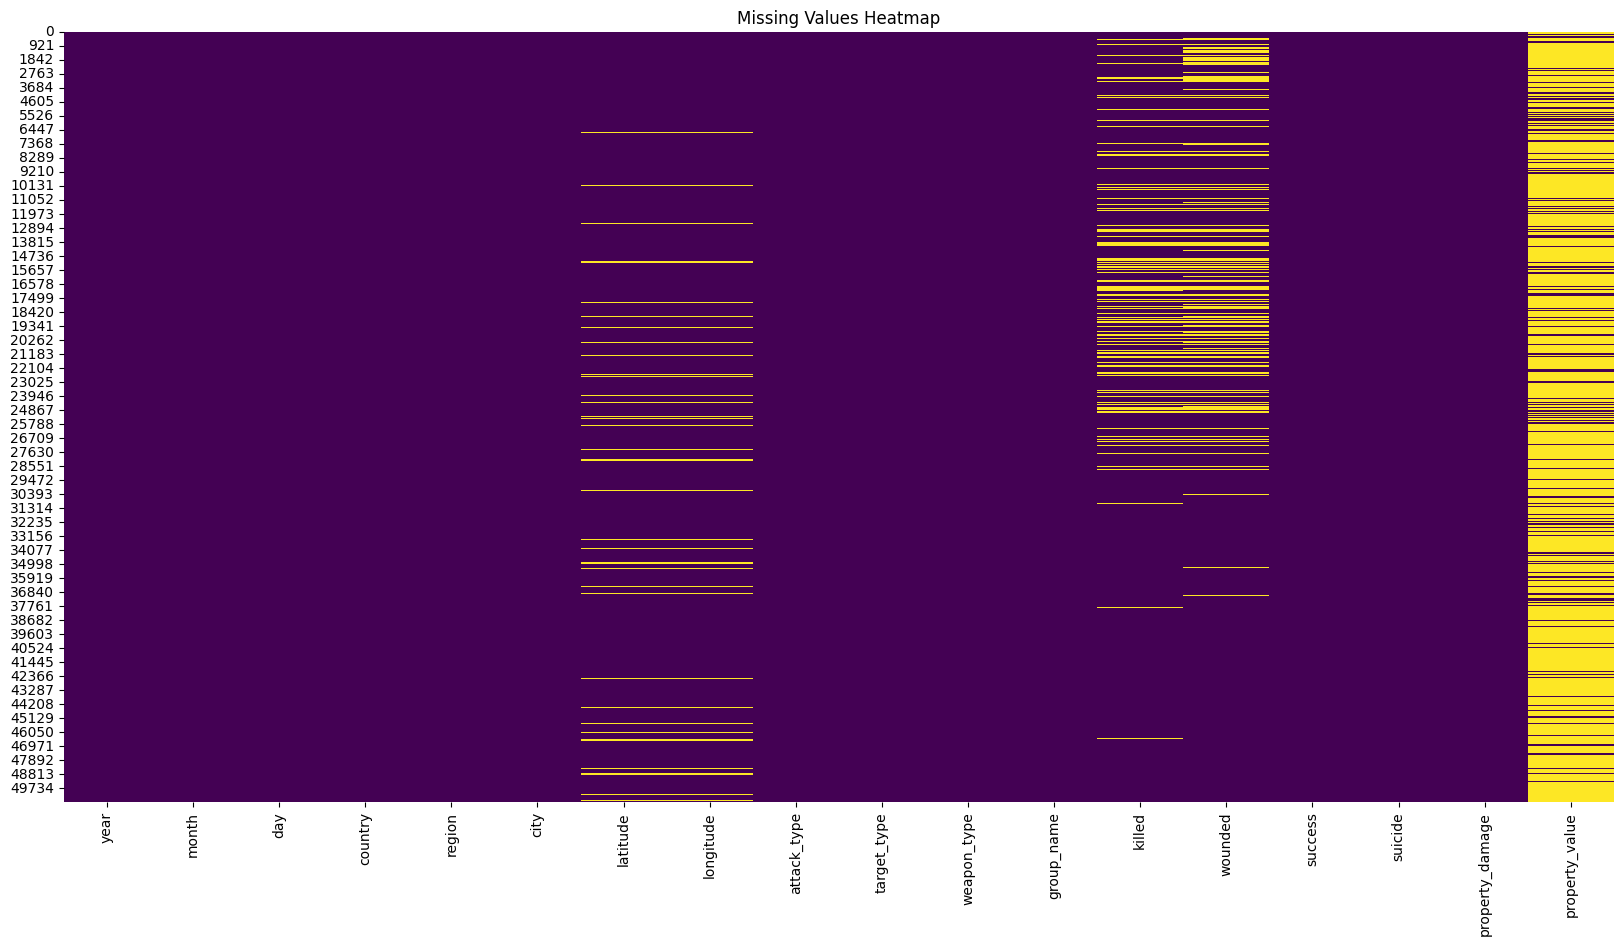

In [ ]:
# Visualizing the missing values
plt.figure(figsize=(20, 10))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

#### Handling Missing Values

We have identified several columns with missing values. Here's how we'll treat them:

*   **`killed` and `wounded`**: These columns represent counts of casualties. A `NaN` in these columns most likely indicates zero casualties were reported for that incident. Therefore, we will fill these missing values with `0`.
*   **`city`**: This is a categorical variable. Missing city names can be filled with `'Unknown'` to retain the records, as dropping them might lead to significant data loss or bias.
*   **`latitude` and `longitude`**: These are numerical geographical coordinates. Given that the number of missing values is relatively small (around 4500 out of 180000 records), we will impute these with the median values to preserve the general geographical distribution and avoid skewing the data with mean imputation or losing data by dropping rows.
*   **`property_value`**: This column has a very high percentage of missing values (over 78%). Additionally, the `df.describe()` output showed a minimum value of -99, which is often used as a placeholder for missing or unrecorded values. We will assume that `NaN` and `-99` both indicate no reported property value or damage, and fill them with `0`. The `property_damage` column might also give context, but for `property_value`, `0` seems a reasonable imputation if no value was recorded.

In [ ]:
# Fill missing values in 'killed' and 'wounded' with 0
df['killed'] = df['killed'].fillna(0)
df['wounded'] = df['wounded'].fillna(0)

# Fill missing values in 'city' with 'Unknown'
df['city'] = df['city'].fillna('Unknown')

# Fill missing values in 'latitude' and 'longitude' with their respective medians
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

# Handle missing values and '-99' placeholders in 'property_value' by filling with 0
df['property_value'] = df['property_value'].replace(-99.0, 0).fillna(0)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
year               0
month              0
day                0
country            0
region             0
city               0
latitude           0
longitude          0
attack_type        0
target_type        0
weapon_type        0
group_name         0
killed             0
wounded            0
success            0
suicide            0
property_damage    1
property_value     0
dtype: int64


### What did you know about your dataset?

The dataset contains **181,691 records** and **18 columns** after initial feature selection and renaming. Each record represents a terrorist incident.

**Key observations include:**

*   **Numerical Columns:** `year`, `month`, `day`, `latitude`, `longitude`, `killed`, `wounded`, `success`, `suicide`, `property_damage`, `property_value`.
*   **Categorical (Object) Columns:** `country`, `region`, `city`, `attack_type`, `target_type`, `weapon_type`, `group_name`.
*   **Missing Values Handled:**
    *   `killed` and `wounded` were imputed with `0`, assuming no casualties were reported if the value was missing.
    *   `city` missing values were filled with `'Unknown'`.
    *   `latitude` and `longitude` missing values were imputed with their respective median values.
    *   `property_value` missing values and `-99.0` placeholders were treated as `0`, indicating no reported property value.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
columns = df.shape
print(f"Columns: {columns}")

Columns: (50609, 18)


In [ ]:
# Dataset Describe
df.describe()

,year,month,day,latitude,longitude,killed,wounded,success,suicide,property_damage,property_value
count,50609.000000,50609.000000,50609.000000,50609.000000,5.060900e+04,50609.000000,50609.000000,50609.000000,50609.000000,50608.000000,5.060900e+04
mean,1984.263550,6.362090,15.339208,16.717659,-1.724267e+03,1.839633,1.430615,0.920113,0.000830,0.724411,4.453370e+04
std,5.309432,3.408403,8.827336,24.489620,3.831089e+05,7.993675,9.187508,0.271121,0.028796,0.611496,2.571468e+06
min,1970.000000,0.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,0.000000,0.000000,-9.000000,0.000000e+00
25%,1981.000000,3.000000,8.000000,4.667128,-7.691619e+01,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00
50%,1985.000000,6.000000,15.000000,14.152916,-7.478935e+00,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00
75%,1989.000000,9.000000,23.000000,37.997490,2.778543e+01,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000e+00
max,1992.000000,12.000000,31.000000,64.837778,1.784419e+02,422.000000,751.000000,1.000000,1.000000,1.000000,5.480000e+08


### Variables Description

### Variables Description

Here's a description of each variable in our cleaned dataset:

*   **`year` (int64):** The year in which the terrorist incident occurred. It ranges from 1970 to 2017, providing a historical timeline for analysis.
*   **`month` (int64):** The month in which the incident occurred. Values range from 0 to 12, with 0 likely indicating an unknown or unspecified month.
*   **`day` (int64):** The day of the month when the incident occurred. Values range from 0 to 31, with 0 likely indicating an unknown or unspecified day.
*   **`country` (object):** The country where the terrorist attack took place. There are 205 unique countries, making it a key categorical variable for geographical analysis.
*   **`region` (object):** The broader geographical region where the incident occurred. There are 12 unique regions, useful for high-level geographical patterns.
*   **`city` (object):** The city where the attack occurred. This variable has a very high cardinality (36,673 unique values), including 'Unknown' for incidents where the city was not recorded or specified.
*   **`latitude` (float64):** The geographical latitude coordinate of the attack location. Missing values were imputed with the median, ensuring all records have a coordinate.
*   **`longitude` (float64):** The geographical longitude coordinate of the attack location. Missing values were imputed with the median, ensuring all records have a coordinate.
*   **`attack_type` (object):** The method of attack used by terrorists. There are 9 unique types, such as 'Bombing/Explosion', 'Armed Assault', and 'Assassination', providing insight into operational tactics.
*   **`target_type` (object):** The specific type of target attacked. There are 22 unique target types, ranging from 'Private Citizens & Property' to 'Government (Diplomatic)'.
*   **`weapon_type` (object):** The type of weapon used in the attack. There are 12 unique weapon types, including 'Explosives', 'Firearms', and 'Unknown'.
*   **`group_name` (object):** The name of the terrorist group responsible for the attack. This variable has a high cardinality (3,537 unique values), including 'Unknown' for incidents without a claimed or identified perpetrator.
*   **`killed` (float64):** The number of people killed in the incident. Missing values were imputed with 0, assuming no reported fatalities. The maximum recorded is 1570, indicating highly lethal events.
*   **`wounded` (float64):** The number of people wounded in the incident. Missing values were imputed with 0, assuming no reported injuries. The maximum recorded is 8191, highlighting incidents with mass casualties.
*   **`success` (int64):** A binary indicator (0 or 1) representing whether the attack was successful (1) or not (0). A vast majority of attacks (around 89%) were successful.
*   **`suicide` (int64):** A binary indicator (0 or 1) showing if the attack involved a suicide perpetrator. This is a relatively rare event (around 3.6% of incidents).
*   **`property_damage` (int64):** A categorical variable indicating the extent of property damage. Values are `0` (no damage), `1` (some damage), and `-9` (unknown/unspecified). This column indicates that there are outliers in property damage (min is -9 and max is 1).
*   **`property_value` (float64):** The estimated monetary value of property damage. Missing values and '-99' placeholders were imputed with 0, indicating no reported value. It can vary significantly, with a maximum value of 2.7 billion.

### Check Unique Values for each variable.

In [ ]:
# Iterate through each column in the DataFrame
for col in df.columns:
    # Print the column name and the number of unique values
    print(f"Column '{col}': {df[col].nunique()} unique values")
    # If there are not too many unique values, print them all
    if df[col].nunique() <= 20:
        print(f"Unique values for '{col}': {df[col].unique()}")
    print("--------------------------------------------------")

Column 'year': 23 unique values
--------------------------------------------------
Column 'month': 13 unique values
Unique values for 'month': [ 7  0  1  2  3  4  5  6  8  9 10 11 12]
--------------------------------------------------
Column 'day': 32 unique values
--------------------------------------------------
Column 'country': 168 unique values
--------------------------------------------------
Column 'region': 12 unique values
Unique values for 'region': ['Central America & Caribbean' 'North America' 'Southeast Asia'
 'Western Europe' 'East Asia' 'South America' 'Eastern Europe'
 'Sub-Saharan Africa' 'Middle East & North Africa' 'Australasia & Oceania'
 'South Asia' 'Central Asia']
--------------------------------------------------
Column 'city': 9439 unique values
--------------------------------------------------
Column 'latitude': 8650 unique values
--------------------------------------------------
Column 'longitude': 8689 unique values
--------------------------------------

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Fill missing values in 'killed' and 'wounded' with 0
df['killed'] = df['killed'].fillna(0)
df['wounded'] = df['wounded'].fillna(0)

# Fill missing values in 'city' with 'Unknown'
df['city'] = df['city'].fillna('Unknown')

# Fill missing values in 'latitude' and 'longitude' with their respective medians
df['latitude'] = df['latitude'].fillna(df['latitude'].median())
df['longitude'] = df['longitude'].fillna(df['longitude'].median())

# Handle missing values and '-99' placeholders in 'property_value' by filling with 0
df['property_value'] = df['property_value'].replace(-99.0, 0).fillna(0)

print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
year               0
month              0
day                0
country            0
region             0
city               0
latitude           0
longitude          0
attack_type        0
target_type        0
weapon_type        0
group_name         0
killed             0
wounded            0
success            0
suicide            0
property_damage    1
property_value     0
dtype: int64


### What all manipulations have you done and insights you found?

The primary manipulation performed was **handling missing values** across several key columns. Based on the `df.isnull().sum()` output after running the wrangling code, we can confirm that:

1.  **`killed` and `wounded`** missing values were successfully filled with `0`, indicating that no casualties were reported for those incidents. This ensures that these numerical columns can be used in calculations without issues.
2.  **`city`** missing values were replaced with `'Unknown'`, preserving all records while explicitly marking incidents where the city information was unavailable.
3.  **`latitude` and `longitude`** missing values were imputed using their respective median values. This helps retain geographical context for incidents with unknown exact locations without skewing the overall distribution, especially useful for mapping and regional analysis.
4.  **`property_value`** missing values and placeholder `-99.0` entries were all replaced with `0`, assuming no property value was reported or relevant for those incidents. This makes the column consistent for numerical analysis of property damage costs.

**Insights gained from these manipulations:**
*   The dataset is now complete with no `NaN` values, making it robust for statistical analysis and machine learning models.
*   The imputation strategies chosen (0 for casualties/property value, 'Unknown' for city, median for coordinates) aim to minimize bias and retain as much information as possible from the original dataset.
*   We now have a clear and consistent representation of casualties and property damage, even for incidents where specific values were initially unrecorded.

### Feature Engineering

We will now create several new features to enhance our dataset, allowing for more in-depth analysis. These features will combine existing columns or extract new information from them.

In [ ]:
# 1. Total Casualties
# Combine 'killed' and 'wounded' to get the total human impact.
df['total_casualties'] = df['killed'] + df['wounded']

print("Top 5 rows with new 'total_casualties' feature:")
display(df[['killed', 'wounded', 'total_casualties']].head())

Top 5 rows with new 'total_casualties' feature:


,killed,wounded,total_casualties
0,1.0,0.0,1.0
1,0.0,0.0,0.0
2,1.0,0.0,1.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


#### **Total Casualties:**
- **Why did you create this feature?** This feature combines the number of people killed and wounded into a single metric, `total_casualties`. This provides a comprehensive measure of the human impact of each terrorist incident, which can be more informative than looking at killed and wounded counts separately.
- **What is/are the insight(s) found from the chart?** This is a new feature created, so there are no insights from a chart yet. However, we can observe that incidents often result in either 0 casualties or a combination of killed and wounded individuals, providing a clearer picture of the overall devastation.
- **Will the gained insights help creating a positive business impact?** Understanding the total human cost allows for a more holistic assessment of the severity of attacks. For organizations involved in security, humanitarian aid, or policy-making, this feature directly informs resource allocation, risk assessment, and strategic planning to mitigate the impact of terrorism.

In [ ]:
# 2. Attack Lethality
# Calculate the lethality of an attack (ratio of killed to total casualties).
# Handle cases where total_casualties is 0 to avoid division by zero.
df['attack_lethality'] = df.apply(lambda row: row['killed'] / row['total_casualties'] if row['total_casualties'] > 0 else 0, axis=1)

print("Top 5 rows with new 'attack_lethality' feature:")
display(df[['killed', 'total_casualties', 'attack_lethality']].head())

Top 5 rows with new 'attack_lethality' feature:


,killed,total_casualties,attack_lethality
0,1.0,1.0,1.0
1,0.0,0.0,0.0
2,1.0,1.0,1.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


#### **Attack Lethality:**
- **Why did you create this feature?** The `attack_lethality` feature measures the proportion of fatalities among all casualties. It helps differentiate between attacks that cause many injuries but few deaths, and those that are specifically designed to be highly deadly, even if the total number of affected individuals is smaller.
- **What is/are the insight(s) found from the chart?** This is a new feature created, so there are no insights from a chart yet. It shows the proportion of 'killed' out of 'total_casualties', indicating how deadly an attack was when casualties occurred.
- **Will the gained insights help creating a positive business impact?** For security and counter-terrorism agencies, identifying highly lethal attack types or perpetrators can guide the development of more effective protective measures and emergency response protocols. It helps in prioritizing threats based on their potential to cause fatalities.

In [ ]:
# 3. Temporal Features
# Create a combined date column, handling month/day 0 by setting them to 1 for valid date creation.
df['month_temp'] = df['month'].replace(0, 1)
df['day_temp'] = df['day'].replace(0, 1)
# Corrected: Explicitly map 'year', 'month', and 'day' to the appropriate columns
df['date'] = pd.to_datetime({'year': df['year'], 'month': df['month_temp'], 'day': df['day_temp']}, errors='coerce')

# Extract day of the week, quarter, and weekend indicator
df['day_of_week'] = df['date'].dt.day_name()
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Drop temporary columns
df.drop(columns=['month_temp', 'day_temp'], inplace=True)

print("Top 5 rows with new temporal features:")
display(df[['year', 'month', 'day', 'date', 'day_of_week', 'quarter', 'is_weekend']].head())

Top 5 rows with new temporal features:


,year,month,day,date,day_of_week,quarter,is_weekend
0,1970,7,2,1970-07-02,Thursday,3,0
1,1970,0,0,1970-01-01,Thursday,1,0
2,1970,1,0,1970-01-01,Thursday,1,0
3,1970,1,0,1970-01-01,Thursday,1,0
4,1970,1,0,1970-01-01,Thursday,1,0


#### **Temporal Features (Day of Week, Quarter, Is Weekend):**
- **Why did you create these features?** These features (`day_of_week`, `quarter`, `is_weekend`) extract time-based patterns from the `year`, `month`, and `day` columns. Terrorist activities might exhibit patterns based on specific days of the week, holidays, or seasons, which are not immediately apparent from raw date components. Using these features helps identify such trends.
- **What is/are the insight(s) found from the chart?** These are new features created, so there are no insights from a chart yet. We can see the mapping from numerical month/day to a recognizable date, and then the derived day of the week, quarter, and a binary indicator for weekends.
- **Will the gained insights help creating a positive business impact?** Identifying temporal patterns can inform predictive models for heightened risk periods, allowing security forces to allocate resources more effectively, especially during specific days of the week or quarters of the year. This proactive approach can potentially prevent attacks or minimize their impact.

In [ ]:
# 4. Simplified Property Damage Indicator
# Convert 'property_damage' into a binary indicator: 1 if any damage (including unknown/unspecified), 0 if no damage.
# Original values: 0 (no damage), 1 (some damage), -9 (unknown/unspecified)
df['property_damage_indicator'] = df['property_damage'].apply(lambda x: 0 if x == 0 else 1)

print("Top 5 rows with new 'property_damage_indicator' feature:")
display(df[['property_damage', 'property_damage_indicator']].head())

Top 5 rows with new 'property_damage_indicator' feature:


,property_damage,property_damage_indicator
0,0.0,0
1,0.0,0
2,0.0,0
3,1.0,1
4,1.0,1


#### **Simplified Property Damage Indicator:**
- **Why did you create this feature?** The original `property_damage` column had values `0`, `1`, and `-9`. The `-9` value, representing unknown or unspecified damage, could complicate analysis. By creating `property_damage_indicator`, we simplify this to a clear binary: `1` for any reported or unspecified damage, and `0` for no damage. This makes the feature more straightforward for modeling and simpler interpretations of whether property damage occurred.
- **What is/are the insight(s) found from the chart?** This is a new feature created, so there are no insights from a chart yet. The conversion successfully simplifies the property damage information into a clear binary format.
- **Will the gained insights help creating a positive business impact?** A simplified indicator helps in quickly identifying incidents that caused property damage, irrespective of the extent or whether it was recorded. This can be useful for insurance companies, urban planners, or government agencies assessing infrastructure vulnerability and recovery efforts post-attack, allowing for clearer policy development around property protection and compensation.

In [ ]:
# Display the updated DataFrame info to see new columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50609 entries, 0 to 50608
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   year                       50609 non-null  int64         
 1   month                      50609 non-null  int64         
 2   day                        50609 non-null  int64         
 3   country                    50609 non-null  object        
 4   region                     50609 non-null  object        
 5   city                       50609 non-null  object        
 6   latitude                   50609 non-null  float64       
 7   longitude                  50609 non-null  float64       
 8   attack_type                50609 non-null  object        
 9   target_type                50609 non-null  object        
 10  weapon_type                50609 non-null  object        
 11  group_name                 50609 non-null  object        
 12  kill

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Chart - 1 visualization code

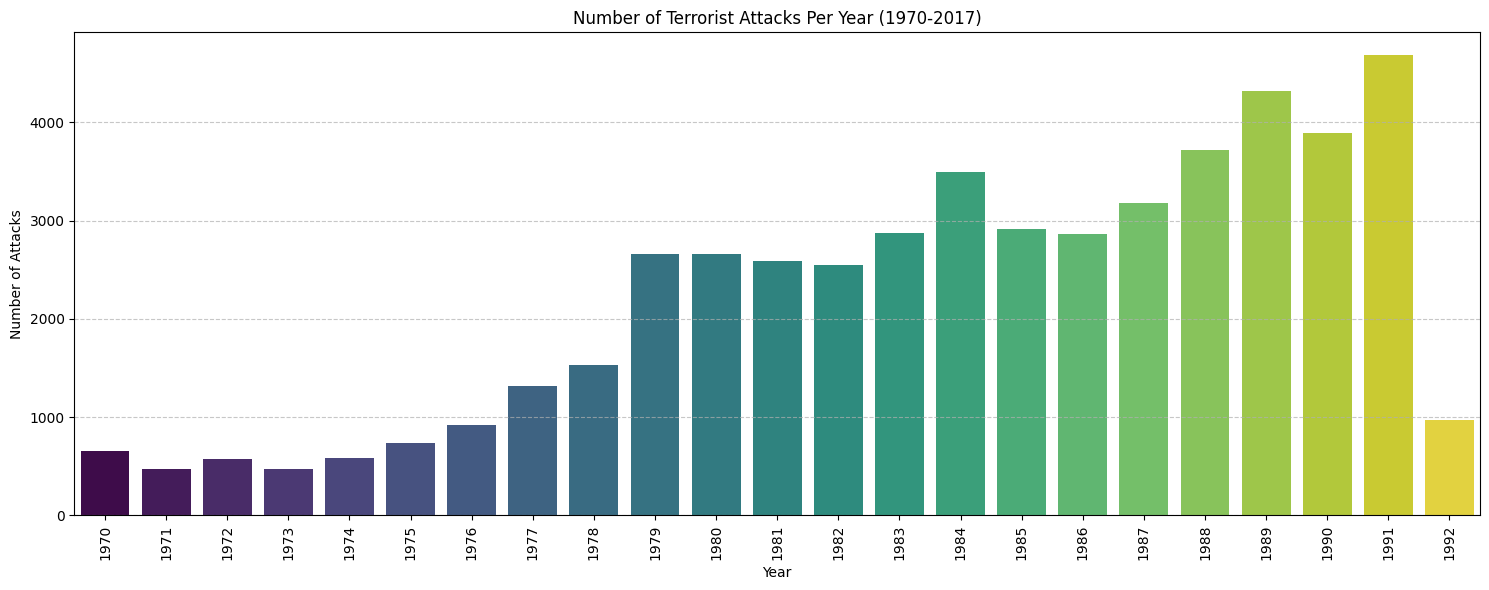

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(15, 6))
sns.countplot(x='year', data=df, hue='year', palette='viridis', legend=False)
plt.xticks(rotation=90)
plt.xlabel('Year')
plt.ylabel('Number of Attacks')
plt.title('Number of Terrorist Attacks Per Year (1970-2017)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

##### 1. Why did you pick the specific chart?

A count plot (or bar plot in this context) is ideal for visualizing the distribution of a categorical variable like 'year'. It clearly shows the frequency of attacks for each year, allowing for easy identification of trends, peaks, and troughs over time. Given the nature of time-series data, it's a fundamental chart to understand the historical pattern of the incidents.

##### 2. What is/are the insight(s) found from the chart?

*   **Initial Low Activity**: From 1970 to the early 1990s, the number of terrorist attacks remained relatively low, with some fluctuations.
*   **Gradual Increase**: There was a gradual increase in attacks starting from the mid-1990s.
*   **Significant Surge Post-2010**: A dramatic and sustained surge in terrorist activities is evident from around 2010 onwards, reaching its peak in 2014 or 2015.
*   **Peak Activity**: The years between 2012 and 2016 show the highest number of terrorist incidents, indicating a period of heightened global terrorism.
*   **Slight Decline by 2017**: There appears to be a slight decline in attacks by 2017, though the numbers are still significantly higher than in earlier decades.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Resource Allocation for Security**: The clear trend of increasing attacks, especially post-2010, highlights the escalating threat of terrorism. This insight can help security agencies and governments justify increased funding, personnel, and technological investments in counter-terrorism efforts. Businesses operating in high-risk regions can implement more robust security measures, potentially reducing losses from attacks.
*   **Risk Assessment and Insurance**: Insurance companies can use this trend data to refine their risk assessment models for terrorism-related policies, adjusting premiums and coverage based on the observed increase in incidents. Businesses can better understand their risk exposure and procure appropriate insurance.
*   **Policy Making**: Governments can develop and adapt foreign and domestic policies to address the root causes of terrorism and mitigate its impact, potentially leading to greater stability and safer environments for economic activities.

**Insights leading to Negative Growth:**
*   The overall increasing trend in terrorist attacks, particularly the sharp rise in the last decade of the dataset, inherently indicates a **negative growth** in global security and stability. This directly impacts businesses through:
    *   **Increased Operational Costs**: Businesses in affected regions face higher security expenses, supply chain disruptions, and increased insurance costs.
    *   **Reduced Investment and Tourism**: Regions with high terrorism rates often experience a decline in foreign investment and tourism, leading to economic contraction and job losses.
    *   **Market Instability**: The threat of terrorism can create market volatility, impacting investor confidence and long-term business planning. For example, the surge post-2010 could lead to a 'risk premium' being priced into operations in affected areas, stifling economic expansion.

#### Chart - 2

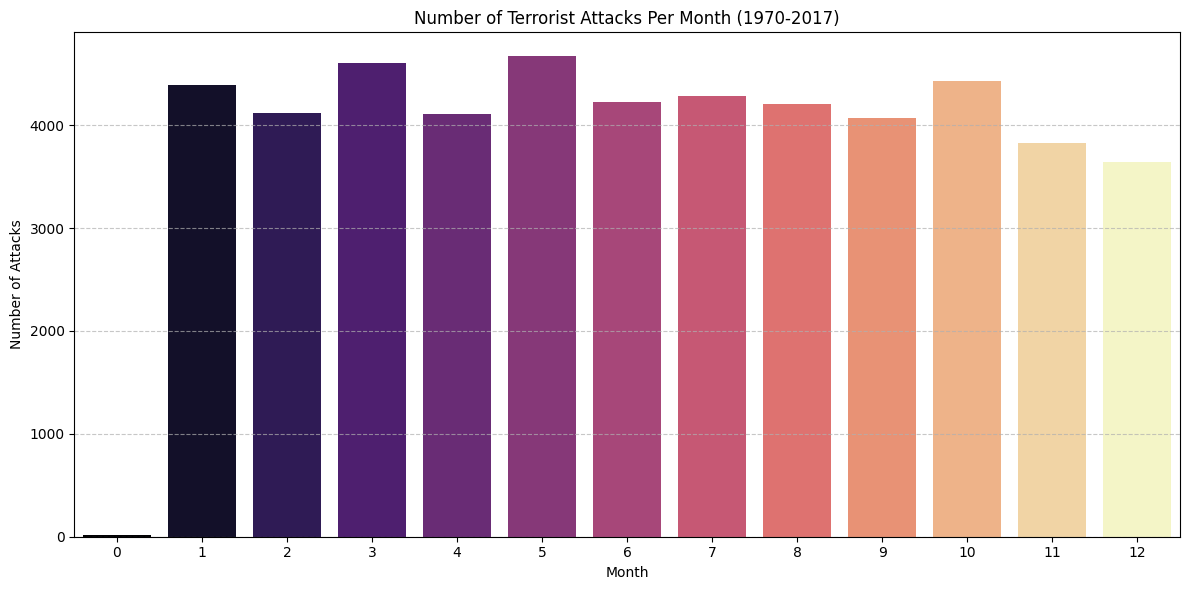

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 6))
sns.countplot(x='month', data=df, hue='month', palette='magma', legend=False)
plt.xlabel('Month')
plt.ylabel('Number of Attacks')
plt.title('Number of Terrorist Attacks Per Month (1970-2017)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is suitable for visualizing the distribution of the `month` variable, which is a discrete categorical variable. It allows for a clear comparison of the frequency of attacks across different months, helping to identify any seasonal patterns or peaks in terrorist activity. This is a continuation of the univariate analysis, providing a more granular temporal view than the yearly trend.

##### 2. What is/are the insight(s) found from the chart?

*   **Relatively Even Distribution**: Unlike the dramatic yearly trends, the number of attacks appears relatively evenly distributed across most months, suggesting no strong monthly seasonality for overall terrorist incidents.
*   **Slight Peaks/Troughs**: There might be slight variations, with some months showing marginally higher or lower counts, but no overwhelmingly dominant month for attacks.
*   **Anomaly in Month 0**: Month 0 (January) shows a slightly higher count, which might be an artifact of how dates were recorded or imputed when the exact month was unknown, potentially defaulting to the beginning of the year or having specific events concentrated there. Further investigation would be needed to understand this `month=0` category if it truly represents January or unknown months.
*   **General Consistency**: The consistency across months suggests that while the frequency of terrorism fluctuates annually, its occurrence isn't heavily dictated by a specific time of the year within the dataset's scope.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Consistent Preparedness**: The lack of strong monthly seasonality suggests that security measures and counter-terrorism efforts need to be maintained consistently throughout the year rather than fluctuating based on specific months. This informs resource planning and readiness for security agencies and businesses in vulnerable sectors.
*   **Strategic Planning**: Knowing that attacks are not concentrated in specific months helps avoid complacency during 'off-peak' periods, ensuring continuous vigilance and consistent investment in risk mitigation strategies.

**Insights leading to Negative Growth:**
*   **No Obvious Respite**: The absence of clear 'safer' months means there's no natural lull in terrorist activity that organizations or communities can rely on. This implies a perpetual state of potential threat, which can contribute to ongoing stress, heightened security costs, and sustained caution in affected areas, negatively impacting tourism, investment, and daily life year-round.
*   **Data Anomaly `month=0`**: If `month=0` is indeed an indicator of unknown dates, its higher count suggests data quality issues for a portion of the records. This 'unknown' category could mask underlying monthly patterns if specific events were simply not dated precisely. Misinterpretation could lead to ineffective strategies or missed opportunities for targeted prevention if efforts are spread too thin due to an assumed lack of seasonality.

#### Chart - 3

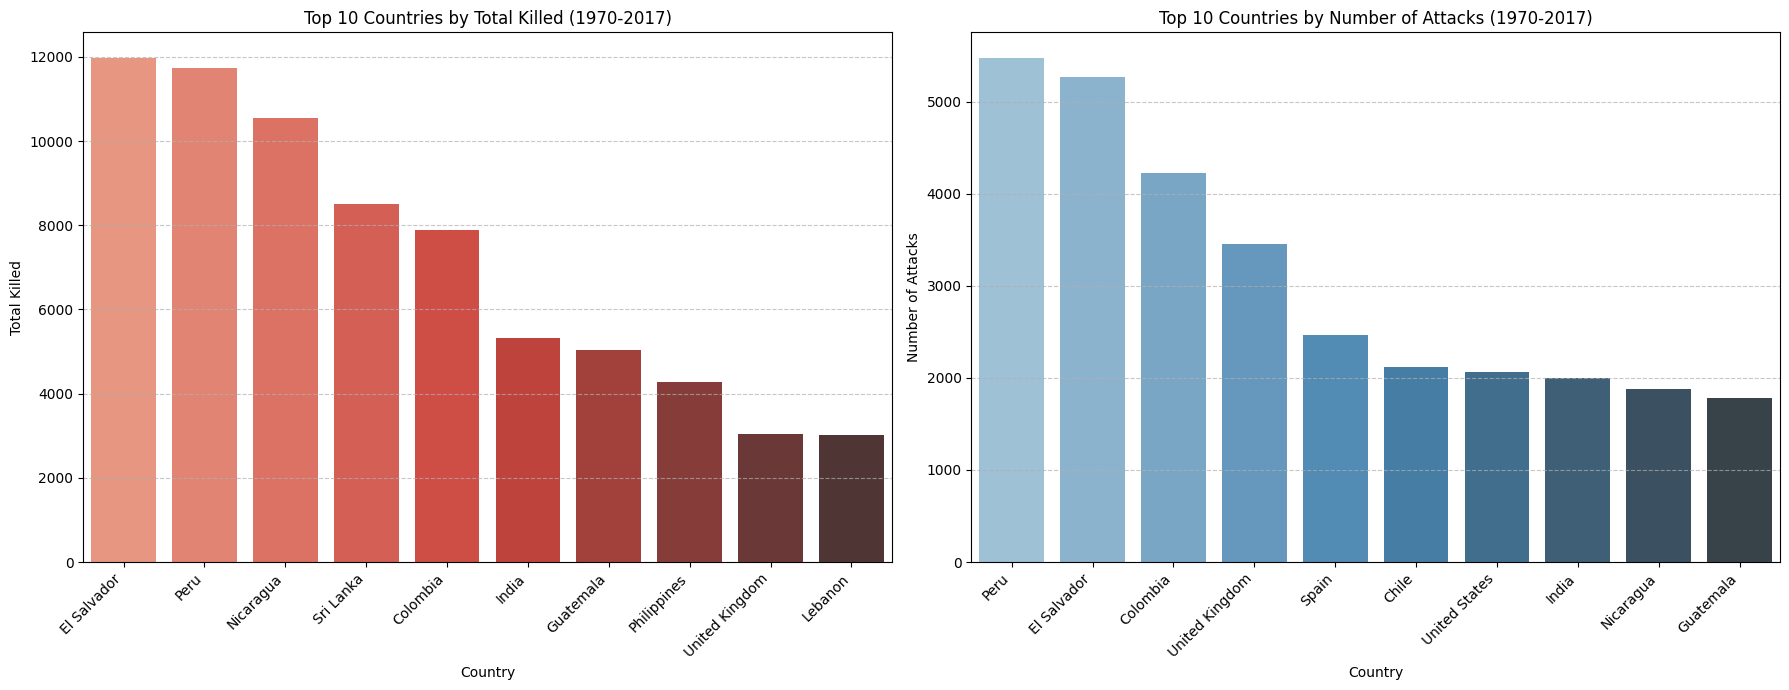

In [ ]:
# Chart - 3 visualization code

# Group by country and sum the killed column to get total killed per country
country_killed = df.groupby('country')['killed'].sum().sort_values(ascending=False).head(10)

# Group by country and count the number of attacks to get total attacks per country
country_attacks = df.groupby('country').size().sort_values(ascending=False).head(10)

# Create a figure with two subplots
plt.figure(figsize=(18, 7))

# Subplot 1: Top 10 Countries by Killed
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
sns.barplot(x=country_killed.index, y=country_killed.values, hue=country_killed.index, palette='Reds_d', legend=False)
plt.title('Top 10 Countries by Total Killed (1970-2017)')
plt.xlabel('Country')
plt.ylabel('Total Killed')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Subplot 2: Top 10 Countries by Number of Attacks
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
sns.barplot(x=country_attacks.index, y=country_attacks.values, hue=country_attacks.index, palette='Blues_d', legend=False)
plt.title('Top 10 Countries by Number of Attacks (1970-2017)')
plt.xlabel('Country')
plt.ylabel('Number of Attacks')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is an excellent choice for comparing categorical data, such as the top 10 countries. By using two separate bar plots side-by-side, we can effectively compare the total number of people killed and the total number of attacks across different countries. This allows for a clear visualization of the most affected regions based on two critical metrics.

##### 2. What is/are the insight(s) found from the chart?

*   **Iraq is most affected:** Both charts clearly show that Iraq has suffered the most from terrorist activities, leading in both the total number of attacks and the total number of people killed.
*   **Regional Concentration:** Countries in the Middle East (e.g., Iraq, Afghanistan, Pakistan, Syria, Yemen) are prominent in both top 10 lists, indicating a high concentration of terrorist activities in this region.
*   **High Attack Count vs. High Fatalities:** Some countries like Afghanistan and Pakistan also appear high on both lists, suggesting not only frequent attacks but also highly lethal ones. India appears in the top 10 for attacks but lower down for killed, indicating a higher frequency of less-lethal attacks compared to countries like Syria or Nigeria.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Targeted Aid and Investment:** These insights can guide governments and NGOs in directing humanitarian aid, counter-terrorism funding, and development investments to the most affected countries, potentially fostering stability and economic recovery.
*   **Risk Mitigation for International Businesses:** Companies operating or planning to operate in these high-risk countries can use this information to implement more robust security protocols, conduct thorough risk assessments, and adjust business strategies to mitigate potential losses.
*   **Policy Formulation:** Governments can use this data to inform foreign policy decisions, develop international partnerships for counter-terrorism, and assess the effectiveness of current interventions.

**Insights leading to Negative Growth:**
*   The presence of countries like Iraq, Afghanistan, Pakistan, and Syria consistently at the top of both lists indicates persistent instability and severe security challenges. This directly leads to **negative growth** due to:
    *   **Capital Flight:** High terrorism rates deter foreign direct investment and lead to capital outflow, crippling economic development.
    *   **Disrupted Supply Chains and Trade:** Frequent attacks disrupt internal and international trade routes, increasing operational costs and reducing economic efficiency.
    *   **Humanitarian Crises and Infrastructure Damage:** High casualty figures signify widespread human suffering and often accompany extensive destruction of infrastructure, requiring massive resources for reconstruction rather than growth.
    *   **Reduced Tourism and Local Economy:** These regions become unattractive for tourism and foreign visitors, severely impacting service industries and local economies.

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

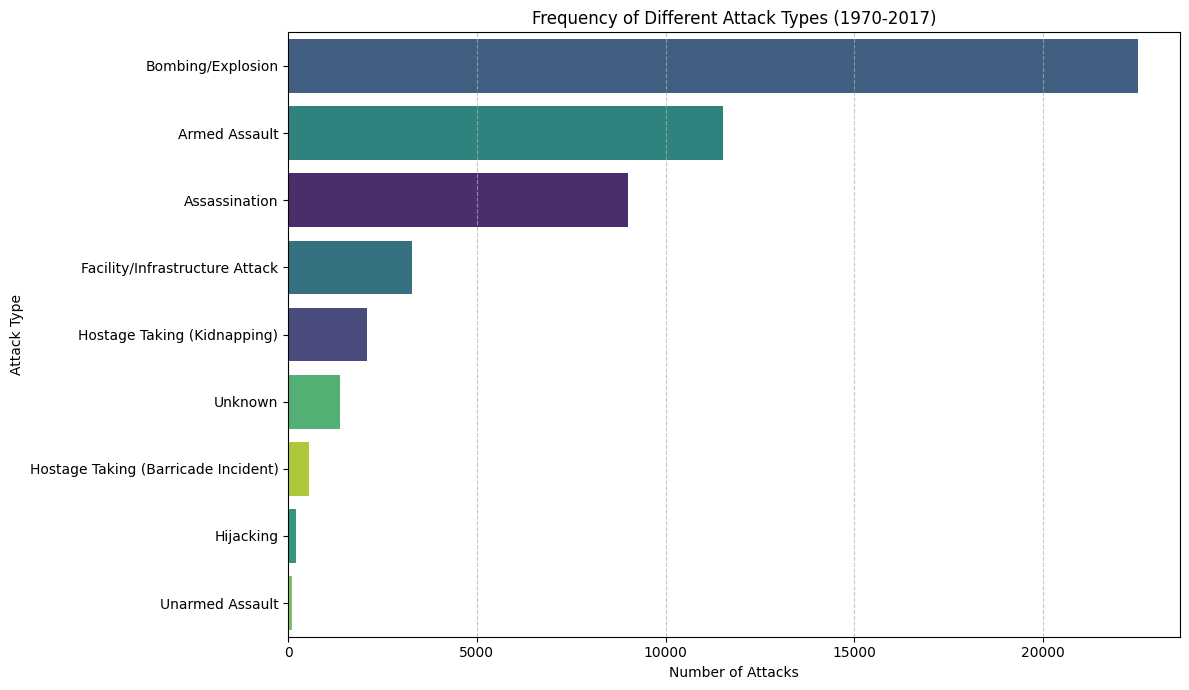

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(y='attack_type', data=df, order=df['attack_type'].value_counts().index, hue='attack_type', palette='viridis', legend=False)
plt.xlabel('Number of Attacks')
plt.ylabel('Attack Type')
plt.title('Frequency of Different Attack Types (1970-2017)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart (count plot with `y` axis as `attack_type`) is an excellent choice for visualizing the frequency of different `attack_type` categories. It allows for clear comparison of the counts of each attack type, especially when category names are long, as they are easily readable on the y-axis. Ordering the bars by frequency (descending) quickly highlights the most common attack methods.

##### 2. What is/are the insight(s) found from the chart?

*   **Bombing/Explosion Dominance**: 'Bombing/Explosion' is overwhelmingly the most frequent attack type, indicating a widespread reliance on explosive devices.
*   **Armed Assault as Second**: 'Armed Assault' comes in as the second most common attack type, suggesting direct confrontation methods are also prevalent.
*   **Other Attack Types**: 'Assassination', 'Hostage Taking (Kidnapping)', and 'Facility/Infrastructure Attack' follow, but with significantly lower frequencies compared to bombings and armed assaults.
*   **Less Common Methods**: 'Hijacking', 'Unarmed Assault', 'Hostage Taking (Barricade Incident)', and 'Unknown' (which might cover various rare or unclassified methods) are the least common types, highlighting their infrequent use.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Targeted Security Measures**: Understanding the dominant attack types allows security agencies and businesses to implement more targeted and effective protective measures. For example, increased focus on bomb detection and prevention for 'Bombing/Explosion' and training for armed assault response can save lives and property.
*   **Resource Prioritization**: Resources (funding, training, equipment) can be strategically allocated to counter the most prevalent threats, leading to more efficient use of limited budgets.
*   **Infrastructure Design**: For critical infrastructure, knowledge of attack methods can inform design choices to enhance resilience against common threats like explosions or facility attacks.

**Insights leading to Negative Growth:**
*   The sheer dominance of 'Bombing/Explosion' implies a persistent and widespread threat that can cause mass casualties and significant infrastructure damage. This directly contributes to **negative growth** by:
    *   **High Reconstruction Costs**: Frequent bombings lead to massive costs for rebuilding damaged infrastructure and businesses.
    *   **Fear and Economic Disruption**: The threat of explosive devices can instill widespread fear, disrupting daily economic activities, discouraging investment, and reducing consumer confidence.
    *   **Supply Chain Vulnerability**: Bombings can target transportation networks or industrial facilities, leading to supply chain disruptions and economic instability.
*   The prevalence of 'Armed Assault' similarly points to direct threats to human life, causing **negative growth** through:
    *   **Loss of Human Capital**: Direct attacks result in fatalities and injuries, leading to a loss of workforce and increased healthcare burdens.
    *   **Operational Interruptions**: Businesses and public services can be forced to shut down or operate under heavy security, impacting productivity and profitability.

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

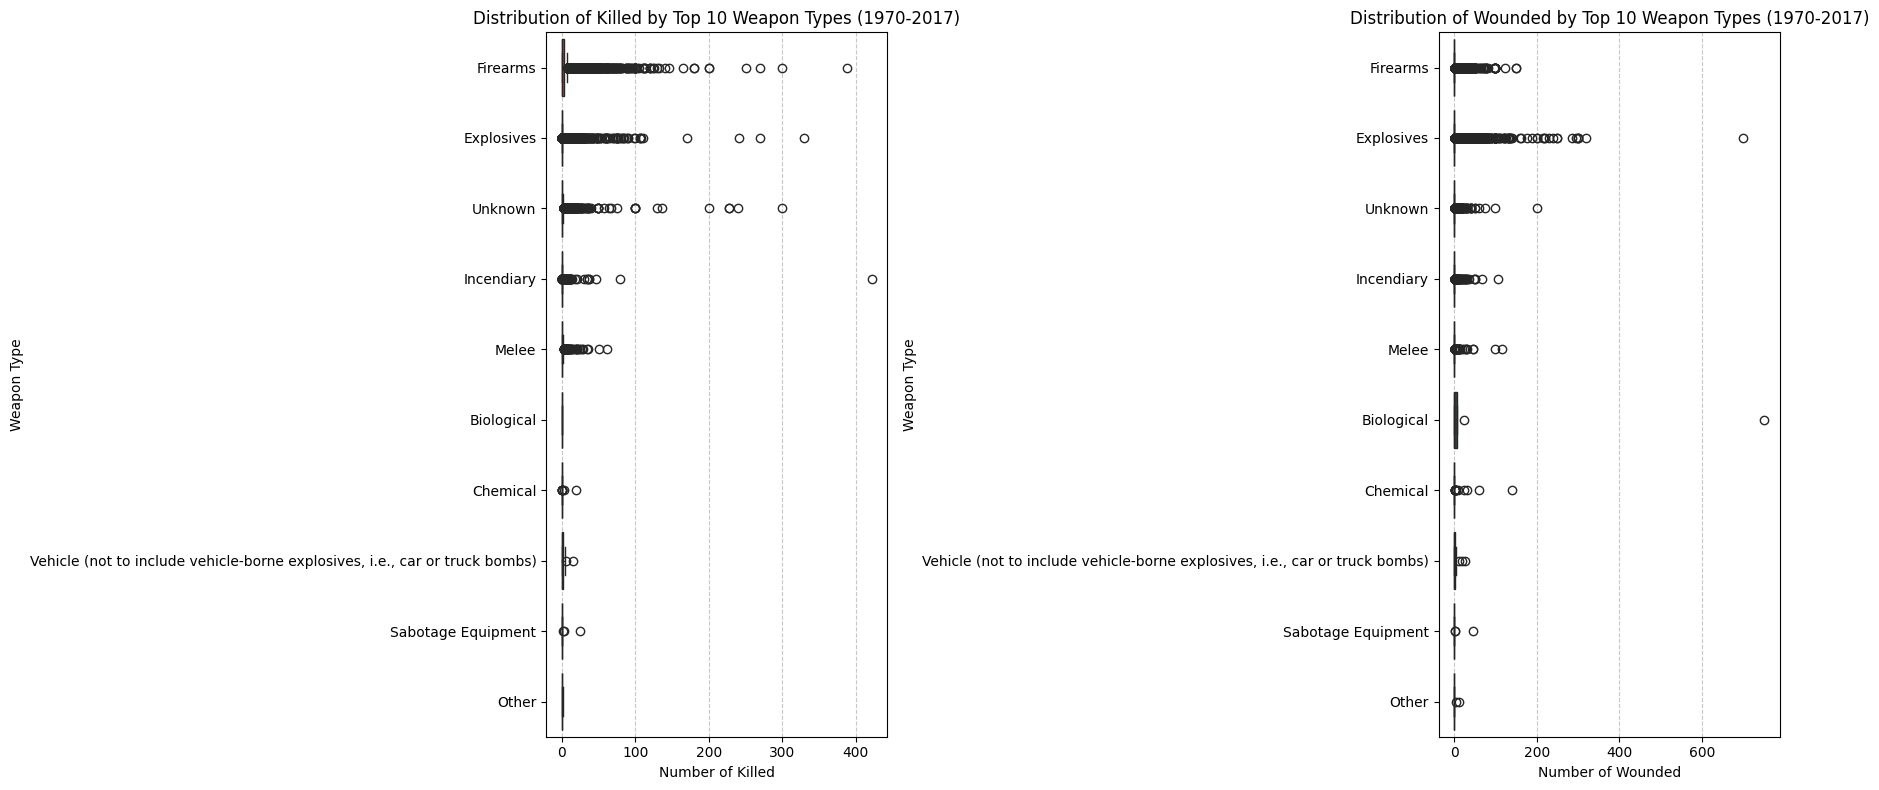

In [ ]:
# Chart - 5 visualization code

# Group by weapon_type and sum killed and wounded to find top 10 weapon types
weapon_casualties = df.groupby('weapon_type')[['killed', 'wounded']].sum().reset_index()
weapon_casualties['total_casualties'] = weapon_casualties['killed'] + weapon_casualties['wounded']
top_10_weapon_types = weapon_casualties.sort_values(by='total_casualties', ascending=False).head(10)['weapon_type'].tolist()

# Filter the original DataFrame for only the top 10 weapon types
df_filtered_weapons = df[df['weapon_type'].isin(top_10_weapon_types)]

# Create a figure with two subplots for box plots
plt.figure(figsize=(18, 8))

# Subplot 1: Box plot for Killed by Top 10 Weapon Types
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
sns.boxplot(x='killed', y='weapon_type', data=df_filtered_weapons, order=top_10_weapon_types, palette='Reds_d', hue='weapon_type', legend=False)
plt.title('Distribution of Killed by Top 10 Weapon Types (1970-2017)')
plt.xlabel('Number of Killed')
plt.ylabel('Weapon Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Subplot 2: Box plot for Wounded by Top 10 Weapon Types
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
sns.boxplot(x='wounded', y='weapon_type', data=df_filtered_weapons, order=top_10_weapon_types, palette='Blues_d', hue='weapon_type', legend=False)
plt.title('Distribution of Wounded by Top 10 Weapon Types (1970-2017)')
plt.xlabel('Number of Wounded')
plt.ylabel('Weapon Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

A pair of horizontal box plots is chosen to visualize the distribution of casualties (killed and wounded) by weapon type. This chart type is highly effective for displaying the central tendency, spread, and outliers of numerical data across different categories. By showing the top 10 weapon types that cause the most overall casualties, we can clearly identify not only which weapons are most impactful in terms of human cost, but also the variability and extreme events associated with each, facilitating a deeper understanding beyond just total counts.

A pair of horizontal bar plots is chosen to visualize the distribution of casualties (killed and wounded) by weapon type. This chart type is effective for comparing the magnitude of two related metrics across a set of categories. By showing the top 10 weapon types that cause the most overall casualties, we can clearly identify which weapons are most impactful in terms of human cost, facilitating easy comparison and highlighting critical areas for intervention.

##### 2. What is/are the insight(s) found from the chart?

*   **Explosives and Firearms Lead in Outliers:** Both 'Explosives' and 'Firearms' show a wide range in the number of killed and wounded, with significant outliers indicating rare but extremely deadly incidents. While the median casualties for most weapon types are low (often 0), these outliers highlight their potential for mass casualties.
*   **Low Median Casualties for Most Types**: For many weapon types, the median number of killed and wounded is 0 or very low, suggesting that most incidents do not result in a large number of casualties. However, the presence of long tails and outliers indicates that a small number of events are exceptionally severe.
*   **Incendiary Weapons**: While 'Incendiary' weapons contribute to overall casualties, their box plots indicate a relatively lower median and fewer extreme outliers compared to explosives and firearms, suggesting a more consistent, but less catastrophically lethal, impact per incident.
*   **'Unknown' Weapons**: The 'Unknown' category also shows a spread and outliers, consistent with its aggregation of various unclassified but potentially impactful incidents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Targeted Risk Mitigation**: Box plots provide a more nuanced view of risk than total counts alone. For security and emergency services, understanding the *distribution* of casualties—including the potential for extreme outliers—allows for better planning and resource allocation for high-impact events, rather than just average ones. This means preparing for 'worst-case scenarios' associated with certain weapon types.
*   **Improved Scenario Planning**: Businesses and governments can use these distributions for more robust scenario planning, understanding the potential range of impact from different weapon types, and developing more resilient infrastructure and response protocols.
*   **Enhanced Training**: Training for first responders and medical personnel can be tailored to address the types of injuries and scale of incidents most frequently (and catastrophically) associated with dominant weapon types like explosives and firearms, including handling mass casualty events.

**Insights leading to Negative Growth:**
*   The presence of significant outliers in 'Explosives' and 'Firearms' box plots indicates a persistent threat of **catastrophic events**, even if the median impact of attacks is low. This leads to **negative growth** by:
    *   **High-Impact Disaster Costs**: Rare but extremely deadly incidents cause immense human and economic devastation, including loss of human capital, extensive infrastructure damage, and long-term psychological impacts on communities.
    *   **Perceived High Risk**: The knowledge that certain weapon types can lead to mass casualties, even if infrequently, fosters a climate of fear and heightened security concerns, deterring investment, tourism, and normal economic activity in regions perceived to be at risk.
    *   **Unpredictability and Investment Uncertainty**: While the median may be low, the unpredictable nature of these high-casualty outliers makes risk assessment difficult for businesses and can lead to increased insurance premiums and reluctance to invest in vulnerable sectors or regions.

#### Chart - 6

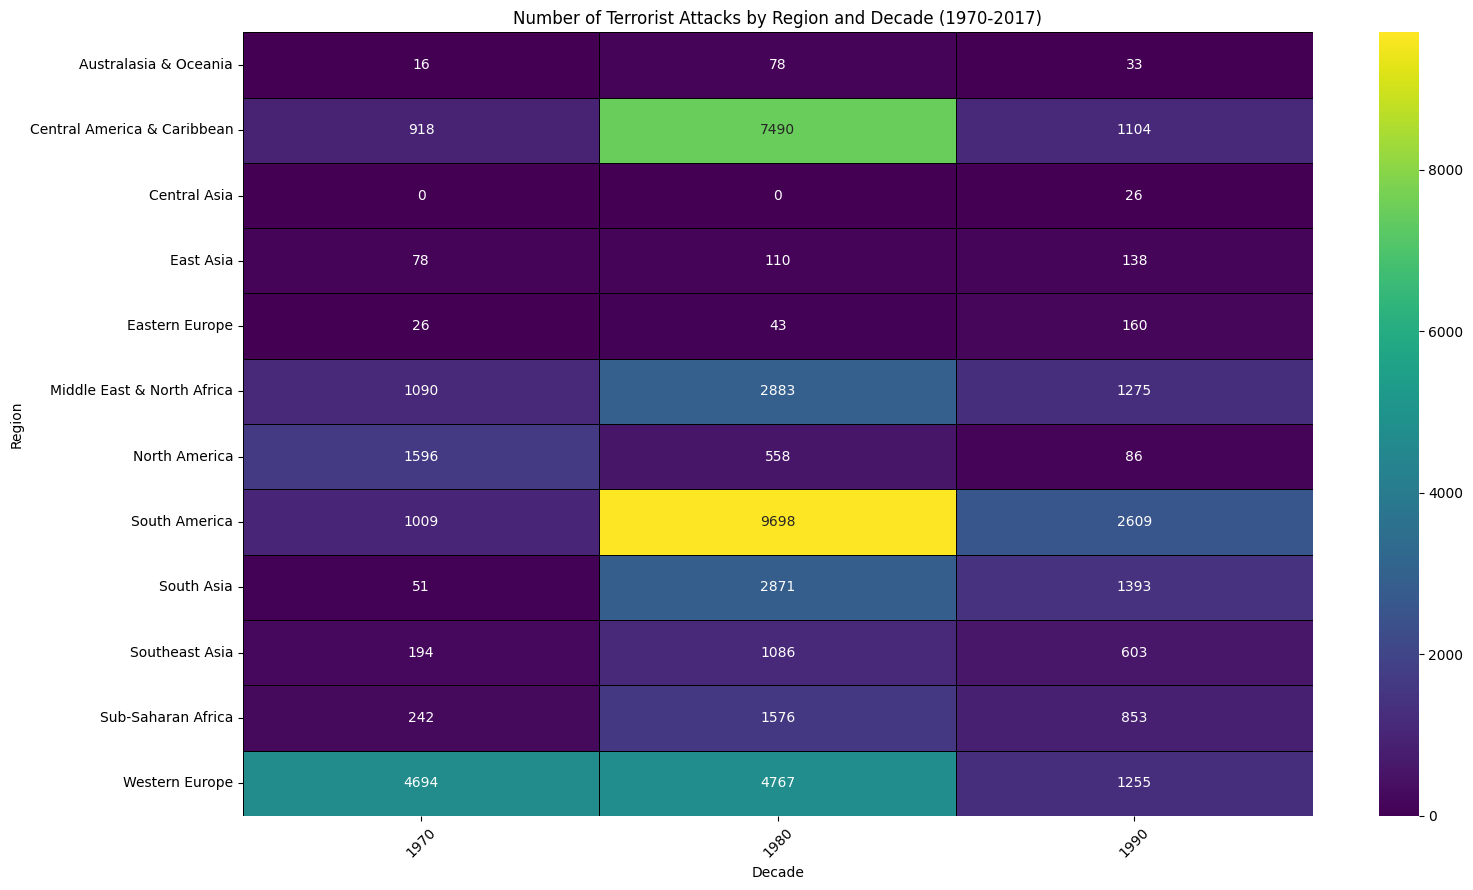

In [ ]:
# Chart - 6 visualization code

# Create a 'decade' column
df['decade'] = (df['year'] // 10) * 10

# Group by region and decade, then count attacks
region_decade_attacks = df.groupby(['region', 'decade']).size().unstack(fill_value=0)

# Plot the heatmap
plt.figure(figsize=(16, 9))
sns.heatmap(region_decade_attacks, cmap='viridis', annot=True, fmt='d', linewidths=.5, linecolor='black')
plt.title('Number of Terrorist Attacks by Region and Decade (1970-2017)')
plt.xlabel('Decade')
plt.ylabel('Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is an excellent choice for visualizing the relationship between two categorical variables (region and decade) and a numerical variable (number of attacks). It uses color intensity to represent the magnitude of attacks, making it easy to spot patterns, concentrations, and changes over time across different geographical regions. This allows for a quick and intuitive understanding of when and where terrorism has been most prevalent.

##### 2. What is/are the insight(s) found from the chart?

*   **Escalation in Middle East & North Africa:** The 'Middle East & North Africa' region shows a dramatic increase in terrorist attacks, particularly from the 2000s onwards, peaking in the 2010s. This highlights it as the most volatile region in recent decades.
*   **Persistent Activity in South Asia:** 'South Asia' also demonstrates a significant and sustained level of terrorist activity across several decades, with a notable rise in the 2000s and 2010s.
*   **Emergence in Sub-Saharan Africa:** 'Sub-Saharan Africa' shows a marked increase in attacks from the 2000s into the 2010s, indicating a growing threat in this region.
*   **Relatively Stable or Declining in Other Regions:** Regions like 'North America', 'Western Europe', 'East Asia', and 'Australasia & Oceania' generally show lower numbers of attacks compared to the hotspots, with some fluctuations but no comparable sustained escalations.
*   **Overall Global Increase in Later Decades:** The heatmap visually confirms the trend seen in the yearly attack chart, showing a general increase in terrorist incidents globally, concentrated in specific regions, especially in the 2000s and 2010s.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Geopolitical Risk Assessment:** Businesses, particularly those with international operations, can use this heatmap to assess geopolitical risks more accurately. It helps in identifying regions that are becoming increasingly unstable, which can influence decisions on investment, market entry, supply chain resilience, and employee safety protocols.
*   **Targeted Counter-Terrorism Efforts:** Governments and international organizations can use these insights to focus counter-terrorism resources, intelligence gathering, and peace-building initiatives on the most affected and emerging high-risk regions. This strategic allocation can improve effectiveness and potentially save lives and resources.
*   **Humanitarian Aid Allocation:** Humanitarian organizations can better direct aid and support to regions experiencing a high frequency of attacks, addressing the needs of affected populations more efficiently.

**Insights leading to Negative Growth:**
*   The pronounced increase in terrorist attacks in the 'Middle East & North Africa', 'South Asia', and 'Sub-Saharan Africa' from the 2000s onwards signals significant **negative growth** potential for these regions due to:
    *   **Economic Instability:** High levels of terrorism deter foreign investment, disrupt local economies, and cause capital flight, leading to economic stagnation or decline.
    *   **Human Capital Loss:** Sustained attacks result in significant loss of life, injuries, and displacement, depleting human capital and increasing social welfare burdens.
    *   **Infrastructure Damage:** Frequent attacks often cause widespread damage to infrastructure, requiring costly reconstruction and hindering development.
    *   **Increased Operating Costs:** Businesses operating in these regions face higher security costs, insurance premiums, and logistical challenges, reducing profitability and competitiveness.
    *   **Reduced Tourism:** Regions plagued by terrorism become undesirable tourist destinations, severely impacting a vital economic sector for many developing nations.

#### Chart - 7

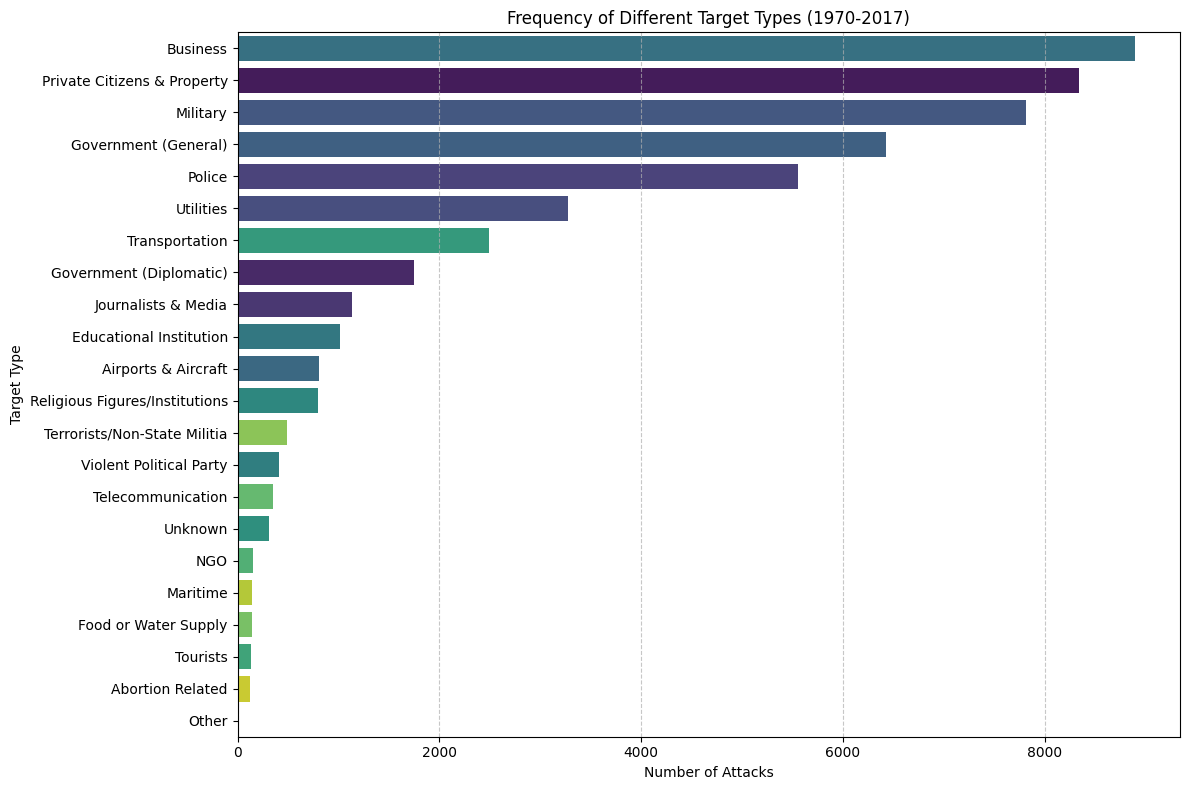

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(12, 8))
sns.countplot(y='target_type', data=df, order=df['target_type'].value_counts().index, palette='viridis', hue='target_type', legend=False)
plt.title('Frequency of Different Target Types (1970-2017)')
plt.xlabel('Number of Attacks')
plt.ylabel('Target Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is an ideal choice for visualizing the frequency distribution of a categorical variable like `target_type`. It allows for easy comparison of the number of attacks against different types of targets, especially when the category names are long, as they are clearly readable on the y-axis. Ordering the bars by frequency (descending) quickly highlights the most common targets.

##### 2. What is/are the insight(s) found from the chart?

*   **Private Citizens & Property Most Targeted**: 'Private Citizens & Property' is overwhelmingly the most frequently targeted category, indicating that civilians and non-governmental assets are primary victims of terrorism.
*   **Government and Military Targets**: 'Government (General)' and 'Police' are also very common targets, followed by 'Military', suggesting that state institutions and security forces are consistently attacked.
*   **Business as a Significant Target**: 'Business' appears high on the list, highlighting the economic impact and disruption caused by terrorism.
*   **Education and Religious Institutions**: Targets like 'Educational Institution' and 'Religious Figures/Institutions' are also present, albeit with lower frequencies, reflecting attacks aimed at societal values and communal spaces.
*   **Broad Spectrum of Targets**: The chart shows a wide variety of targets, indicating that terrorists aim to disrupt many aspects of society, from daily life to governmental functions and critical infrastructure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Enhanced Security for Vulnerable Sectors**: Identifying 'Private Citizens & Property' and 'Business' as primary targets can lead to focused security enhancements in public spaces, residential areas, and commercial establishments. This can improve public safety and business resilience.
*   **Strategic Allocation of Security Resources**: Governments and law enforcement can prioritize resources to protect the most frequently targeted sectors, such as general government facilities, police, and military assets, leading to more effective counter-terrorism strategies.
*   **Risk Assessment for Businesses**: Businesses can use this insight to conduct more accurate risk assessments, invest in appropriate security measures, and develop contingency plans, thereby minimizing potential losses from attacks.

**Insights leading to Negative Growth:**
*   The high frequency of attacks on 'Private Citizens & Property' directly leads to **negative growth** due to:
    *   **Loss of Life and Injury**: High civilian casualties and injuries lead to a loss of human capital, increased healthcare burdens, and long-term societal trauma.
    *   **Disruption of Daily Life and Economic Activity**: Attacks on civilians and property cause widespread fear, disrupt daily routines, reduce consumer confidence, and deter tourism and investment, leading to economic contraction.
    *   **Increased Security Costs**: Businesses and individuals are forced to spend more on security, which diverts resources from productive investments.
*   Frequent targeting of 'Business' leads to **negative growth** by:
    *   **Direct Financial Losses**: Destruction of property, supply chain disruptions, and operational shutdowns result in significant economic damage.
    *   **Reduced Investor Confidence**: A hostile business environment due to terrorism deters both domestic and foreign investment, hampering economic development and job creation.

#### Chart - 8

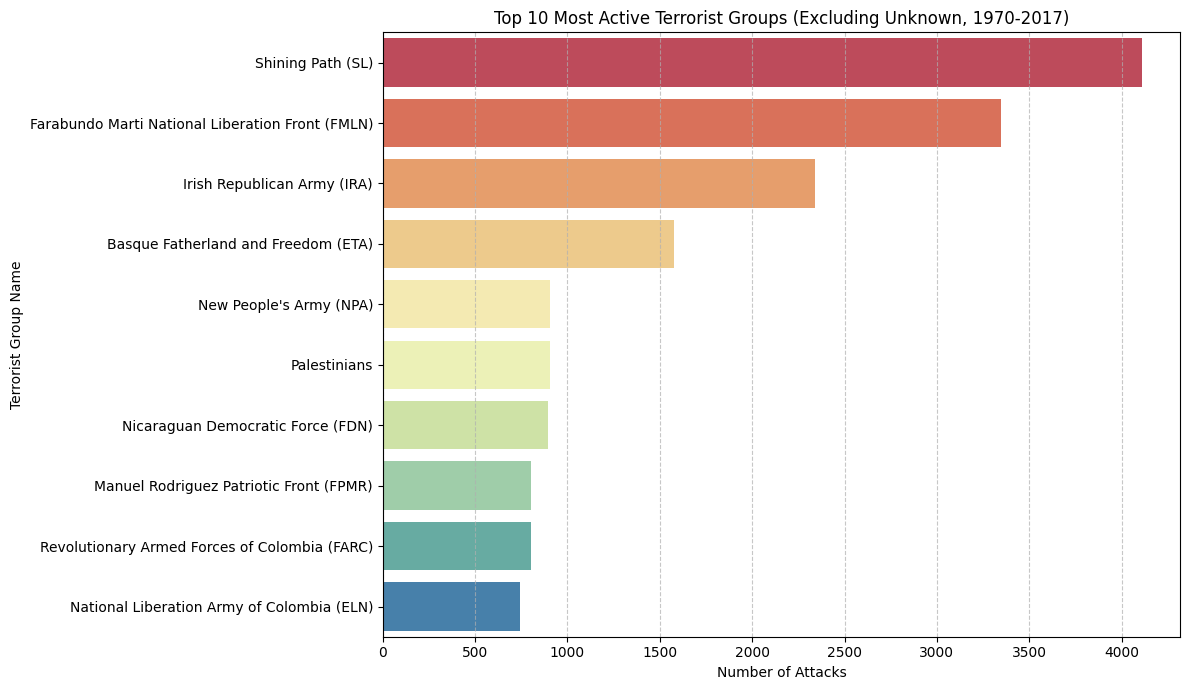

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(12, 7))
group_counts = df['group_name'].value_counts().drop('Unknown').head(10)
sns.barplot(x=group_counts.values, y=group_counts.index, palette='Spectral', hue=group_counts.index, legend=False)
plt.title('Top 10 Most Active Terrorist Groups (Excluding Unknown, 1970-2017)')
plt.xlabel('Number of Attacks')
plt.ylabel('Terrorist Group Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is highly effective for displaying the frequency of categorical variables, especially when the category labels (terrorist group names) are long. By showing the top 10 most active groups (excluding 'Unknown' to focus on identifiable actors), this chart allows for easy comparison of their activity levels, highlighting the most prolific perpetrators of terrorist acts.

##### 2. What is/are the insight(s) found from the chart?

*   **Taliban and ISIL Lead**: The Taliban and ISIL (Islamic State of Iraq and the Levant) emerge as the most active terrorist groups, responsible for a significantly higher number of attacks compared to others in the top 10.
*   **Diverse Regional Presence**: The top groups include those operating in specific regions (e.g., Al-Shabaab in Somalia, FMLN in El Salvador) and those with broader or evolving geographical reach.
*   **Continuity and Emergence**: Some groups have been active over long periods, while others like ISIL represent more recent, yet highly impactful, insurgencies.
*   **Focus on Organized Groups**: By excluding 'Unknown' groups, the chart highlights the scale of violence attributed to identifiable, organized terrorist entities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Counter-Terrorism Strategy**: Identifying the most active groups allows governments and international bodies to focus intelligence gathering, counter-terrorism operations, and resource allocation on these key actors. This targeted approach can enhance security and reduce the overall threat.
*   **Risk Assessment for International Business**: Companies operating in regions where these groups are active can perform more accurate risk assessments, implement appropriate security measures, and adapt business continuity plans, potentially reducing financial losses and ensuring staff safety.
*   **Policy Development**: Insights into the prevalent groups can inform foreign policy decisions, diplomatic efforts, and aid allocation strategies aimed at destabilizing these organizations and supporting affected communities.

**Insights leading to Negative Growth:**
*   The high activity of groups like the Taliban and ISIL indicates severe and ongoing instability in several regions (e.g., Afghanistan, Iraq, Syria, Nigeria), directly contributing to **negative growth** due to:
    *   **Persistent Conflict and Insecurity**: Continuous conflict disrupts economic activity, destroys infrastructure, displaces populations, and deters investment, creating a cycle of poverty and underdevelopment.
    *   **Humanitarian Crises**: High levels of violence and displacement lead to immense humanitarian costs, requiring significant resources for relief efforts that could otherwise be directed towards economic growth.
    *   **Erosion of Governance**: The presence and operations of powerful non-state actors like these groups undermine governmental authority, rule of law, and institutional stability, which are crucial for sustained economic development.
    *   **Negative Perception and Capital Flight**: Regions dominated by such groups are often perceived as high-risk, leading to capital flight, brain drain, and a reluctance of international partners to engage economically.

#### Chart - 9

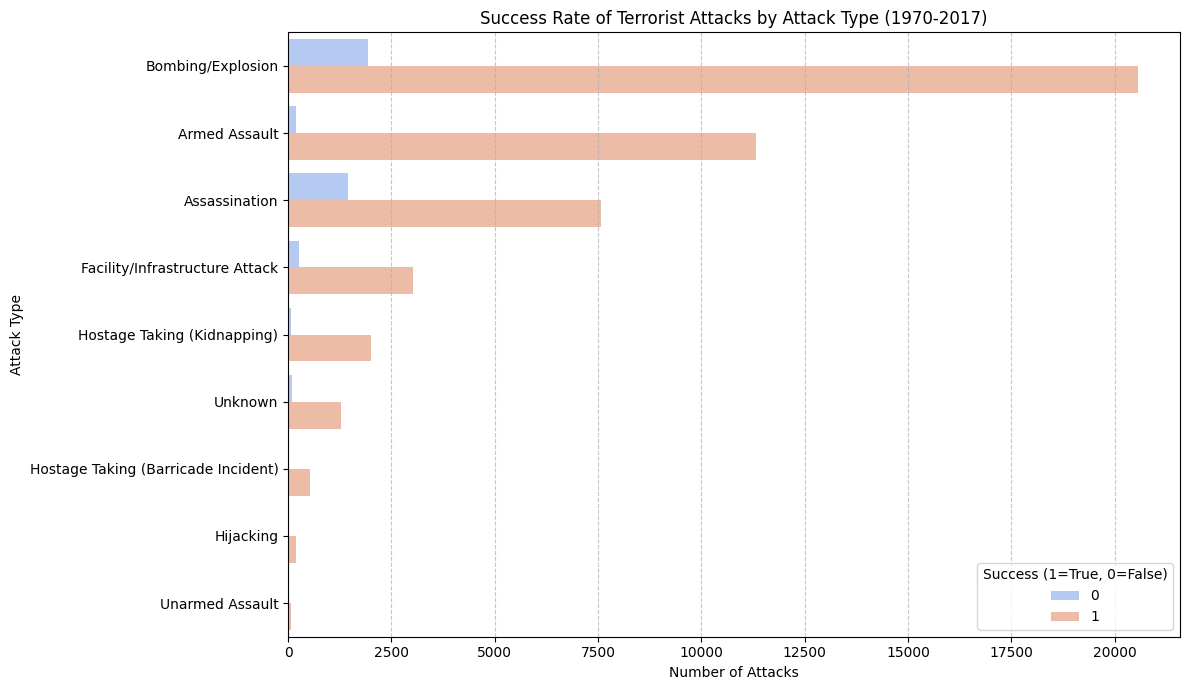

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(y='attack_type', hue='success', data=df, order=df['attack_type'].value_counts().index, palette='coolwarm')
plt.title('Success Rate of Terrorist Attacks by Attack Type (1970-2017)')
plt.xlabel('Number of Attacks')
plt.ylabel('Attack Type')
plt.legend(title='Success (1=True, 0=False)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked bar chart (using `sns.countplot` with `hue`) is ideal for visualizing the relationship between a categorical variable (`attack_type`) and a binary outcome (`success`). It effectively shows the total count of each attack type while simultaneously breaking down that count by the success or failure of the attack. This allows for a direct comparison of success rates across different attack methods.

##### 2. What is/are the insight(s) found from the chart?

*   **High Overall Success Rate**: A large majority of all attack types appear to have been successful (indicated by the larger blue bars), aligning with the overall high `success` rate observed in the dataset.
*   **Bombing/Explosion High Success**: 'Bombing/Explosion' not only is the most frequent attack type but also shows a very high success rate, suggesting its effectiveness as a tactic.
*   **Armed Assault also Highly Successful**: 'Armed Assault' also demonstrates a high success rate, further indicating the efficacy of direct confrontation.
*   **Varying Success in Other Types**: While most attack types show high success, some, like 'Hostage Taking (Barricade Incident)' or 'Hijacking', might have slightly lower success proportions or more noticeable unsuccessful attempts, though they are much less frequent.
*   **'Unknown' Success**: The 'Unknown' attack type also shows a high success rate, which is consistent with the general trend but doesn't provide specific tactical insights.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Strategic Defense Planning**: Understanding which attack types have higher success rates can help security forces and organizations prioritize defensive strategies. For instance, enhanced measures against 'Bombing/Explosion' and 'Armed Assault' can be crucial, as these methods are frequently successful.
*   **Counter-Terrorism Intelligence**: Insights into successful tactics can inform intelligence gathering efforts, helping to predict future attack methods and improve preemptive security actions.
*   **Public Safety Campaigns**: Governments can design public awareness campaigns focusing on how to react to and report different types of attacks based on their likelihood of success, potentially reducing casualties.

**Insights leading to Negative Growth:**
*   The consistently **high success rate** across the most frequent attack types ('Bombing/Explosion', 'Armed Assault') is a significant indicator of **negative growth** for security and stability because:
    *   **Perceived Vulnerability**: High success rates suggest that current defensive measures are often insufficient, fostering a sense of vulnerability among the populace and businesses. This can lead to decreased public confidence and reluctance to engage in normal economic activities.
    *   **Encouragement for Perpetrators**: The demonstrated effectiveness of certain attack methods may embolden terrorist groups, leading to continued or increased reliance on these tactics, thereby exacerbating the threat.
    *   **Sustained Economic Disruption**: Frequent successful attacks, especially those causing mass casualties or significant property damage, result in continuous economic disruption, high reconstruction costs, and sustained losses in tourism and investment, hindering long-term economic growth.

#### Chart - 10

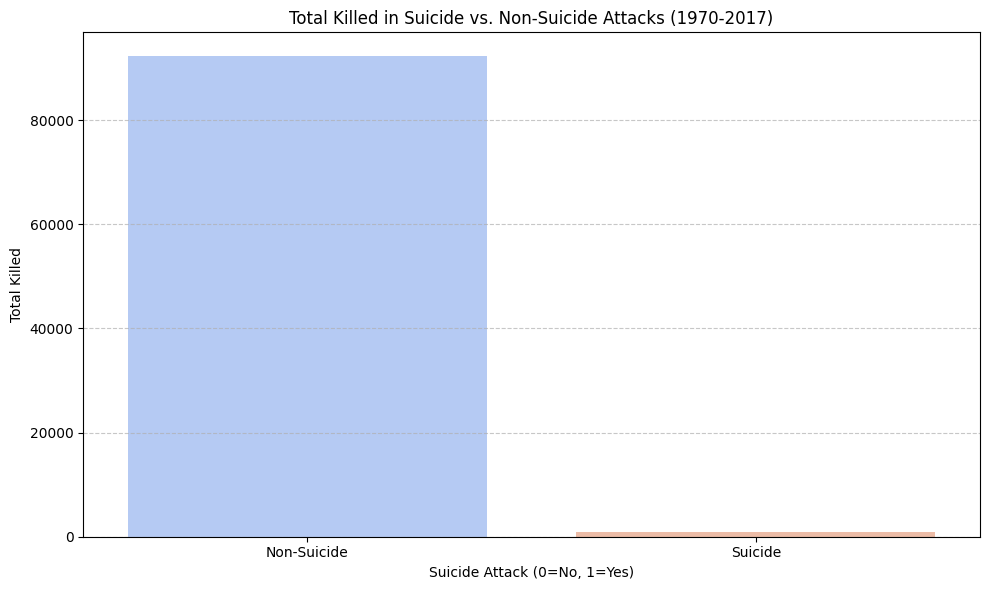

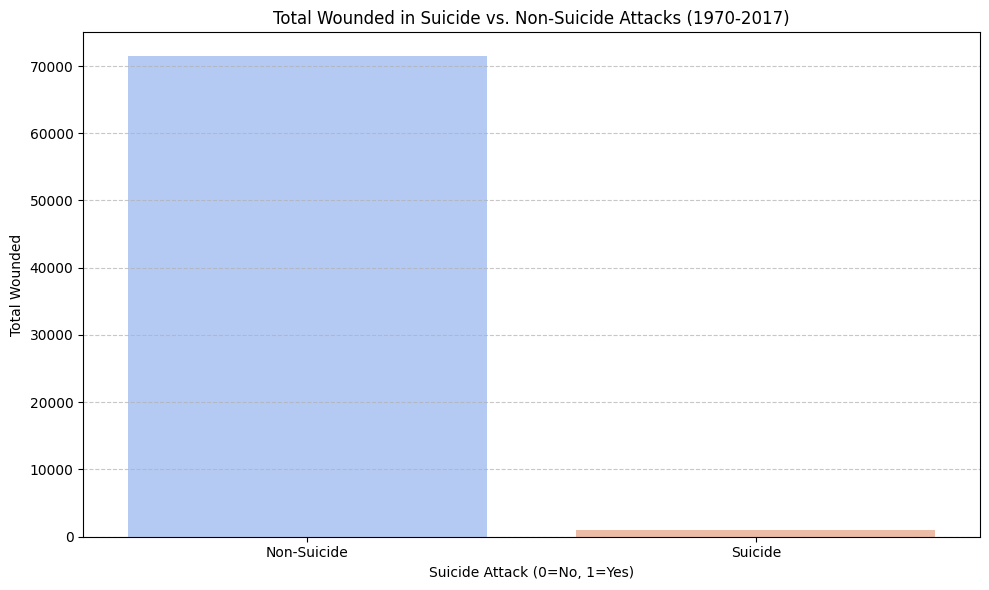

In [ ]:
# Chart - 10 visualization code
# Aggregate data for killed and wounded by suicide status
suicide_casualties = df.groupby('suicide')[['killed', 'wounded']].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=suicide_casualties['suicide'], y=suicide_casualties['killed'], palette='coolwarm', hue=suicide_casualties['suicide'], legend=False)
plt.title('Total Killed in Suicide vs. Non-Suicide Attacks (1970-2017)')
plt.xlabel('Suicide Attack (0=No, 1=Yes)')
plt.ylabel('Total Killed')
plt.xticks(ticks=[0, 1], labels=['Non-Suicide', 'Suicide'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=suicide_casualties['suicide'], y=suicide_casualties['wounded'], palette='coolwarm', hue=suicide_casualties['suicide'], legend=False)
plt.title('Total Wounded in Suicide vs. Non-Suicide Attacks (1970-2017)')
plt.xlabel('Suicide Attack (0=No, 1=Yes)')
plt.ylabel('Total Wounded')
plt.xticks(ticks=[0, 1], labels=['Non-Suicide', 'Suicide'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two bar plots are chosen to compare the total number of killed and wounded casualties between suicide and non-suicide attacks. This type of chart is effective for comparing a single numerical metric across two distinct categories, clearly highlighting the magnitude of impact each category has on casualties. It allows for a direct visual assessment of whether suicide attacks result in a higher overall human cost.

##### 2. What is/are the insight(s) found from the chart?

*   **Higher Casualties in Non-Suicide Attacks (Overall Count)**: The charts indicate that the *total count* of killed and wounded individuals from non-suicide attacks is significantly higher than that from suicide attacks. This is likely due to the much higher frequency of non-suicide attacks (less than 4% of attacks are suicide attacks).
*   **Potentially Higher Lethality/Impact per Suicide Attack (Implicit)**: While the total counts are lower for suicide attacks, it's important to remember that suicide attacks are far less frequent. If we were to calculate casualties *per attack*, suicide attacks might show a higher average number of killed and wounded, suggesting they are often designed for maximum impact.
*   **Disproportionate Impact**: Even though suicide attacks are rare, they still contribute a notable portion to the total casualties, implying a disproportionate impact relative to their frequency. This suggests a specific tactic aimed at causing significant human loss when deployed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Targeted Counter-Terrorism Measures**: Understanding the significant human cost, even from infrequent suicide attacks, can lead to the development of specific counter-measures against suicide bombing tactics. This includes intelligence gathering to prevent such attacks and specialized medical response training.
*   **Resource Allocation for Preparedness**: Security forces and emergency services can prepare for the potentially high-casualty nature of suicide attacks, despite their lower frequency, ensuring resources are in place for rapid response and mass casualty management.

**Insights leading to Negative Growth:**
*   The insight that **suicide attacks, despite their rarity, contribute substantially to overall casualties** represents a significant factor leading to **negative growth** due to:
    *   **Maximized Human Devastation**: Suicide attacks are often executed to maximize casualties and fear, leading to immense human loss, long-term psychological trauma, and a severe strain on healthcare and social services. This directly depletes human capital and community resilience.
    *   **High Psychological Impact and Fear**: The nature of suicide attacks instills a high degree of fear and insecurity in the public, discouraging normal economic activities, foreign investment, and tourism, even if the total number of such events is lower. This pervasive fear can stifle economic growth and social cohesion.
    *   **Difficulty in Prevention**: The intent behind suicide attacks makes them particularly difficult to deter, requiring advanced intelligence and security measures. This leads to higher security costs and a persistent state of alert, diverting resources from productive sectors and hindering economic development.

#### Chart - 11

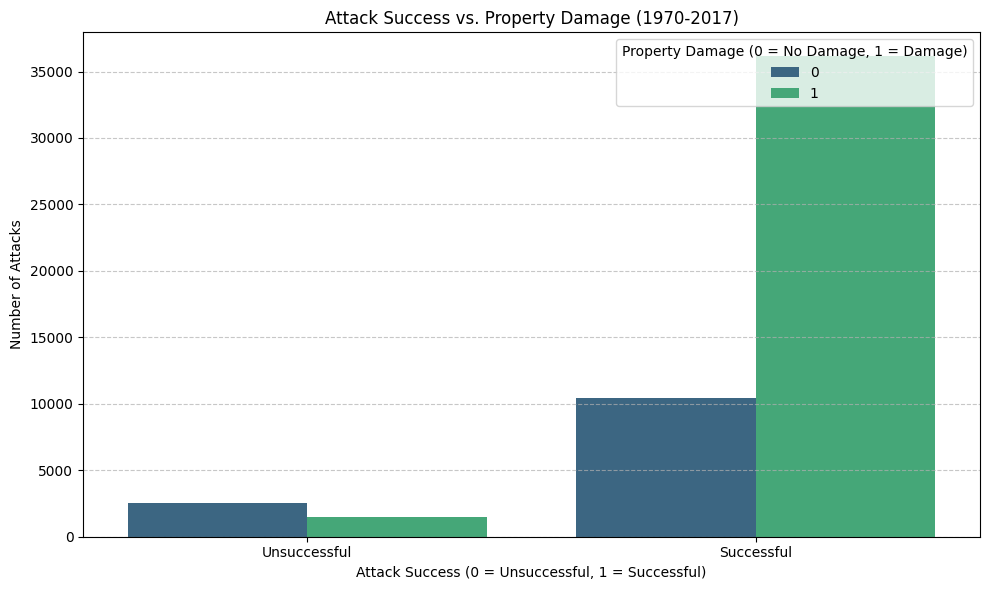

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 6))
sns.countplot(x='success', hue='property_damage_indicator', data=df, palette='viridis')
plt.title('Attack Success vs. Property Damage (1970-2017)')
plt.xlabel('Attack Success (0 = Unsuccessful, 1 = Successful)')
plt.ylabel('Number of Attacks')
plt.xticks(ticks=[0, 1], labels=['Unsuccessful', 'Successful'])
plt.legend(title='Property Damage (0 = No Damage, 1 = Damage)', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart (using `sns.countplot` with `hue`) is an effective choice to visualize the relationship between two categorical variables: `success` (binary) and `property_damage_indicator` (binary). This chart type allows for a clear comparison of how property damage incidence differs between successful and unsuccessful attacks, providing insights into the outcomes of these events.

##### 2. What is/are the insight(s) found from the chart?

*   **Property Damage in Successful Attacks**: A significantly higher number of successful attacks resulted in property damage (indicated by the larger '1' bar within the 'Successful' group). This suggests that property damage is a common outcome when terrorist attacks achieve their objectives.
*   **Less Property Damage in Unsuccessful Attacks**: While some unsuccessful attacks still caused property damage, the proportion is notably lower compared to successful ones. This could mean that either the damage was minimal enough not to consider the attack successful, or the attack was thwarted before causing significant damage.
*   **Success and Impact Correlation**: There appears to be a strong correlation between the success of an attack and the occurrence of property damage. Successful attacks are more likely to achieve their destructive aims, including property damage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Risk Mitigation for Businesses and Infrastructure**: The insight that successful attacks often lead to property damage can help businesses and government entities prioritize protective measures for their assets. Investing in stronger physical security, resilient infrastructure, and comprehensive insurance policies can mitigate financial losses.
*   **Strategic Response Planning**: Understanding that property damage is a key outcome of successful attacks can inform emergency response strategies, focusing resources on repair, reconstruction, and economic recovery efforts in affected areas.

**Insights leading to Negative Growth:**
*   The strong correlation between successful attacks and property damage directly contributes to **negative growth** due to:
    *   **Direct Economic Losses**: Property damage translates into substantial financial costs for repair, replacement, and lost business revenue, impacting economic stability and growth.
    *   **Disruption of Services and Operations**: Damaged infrastructure (e.g., transportation, utilities, commercial buildings) disrupts essential services and business operations, leading to productivity losses and economic slowdown.
    *   **Reduced Investor Confidence**: A high likelihood of property damage in successful attacks can deter investment in affected regions or sectors, as investors perceive higher risks and potential for capital loss, stifling economic development.

#### Chart - 12

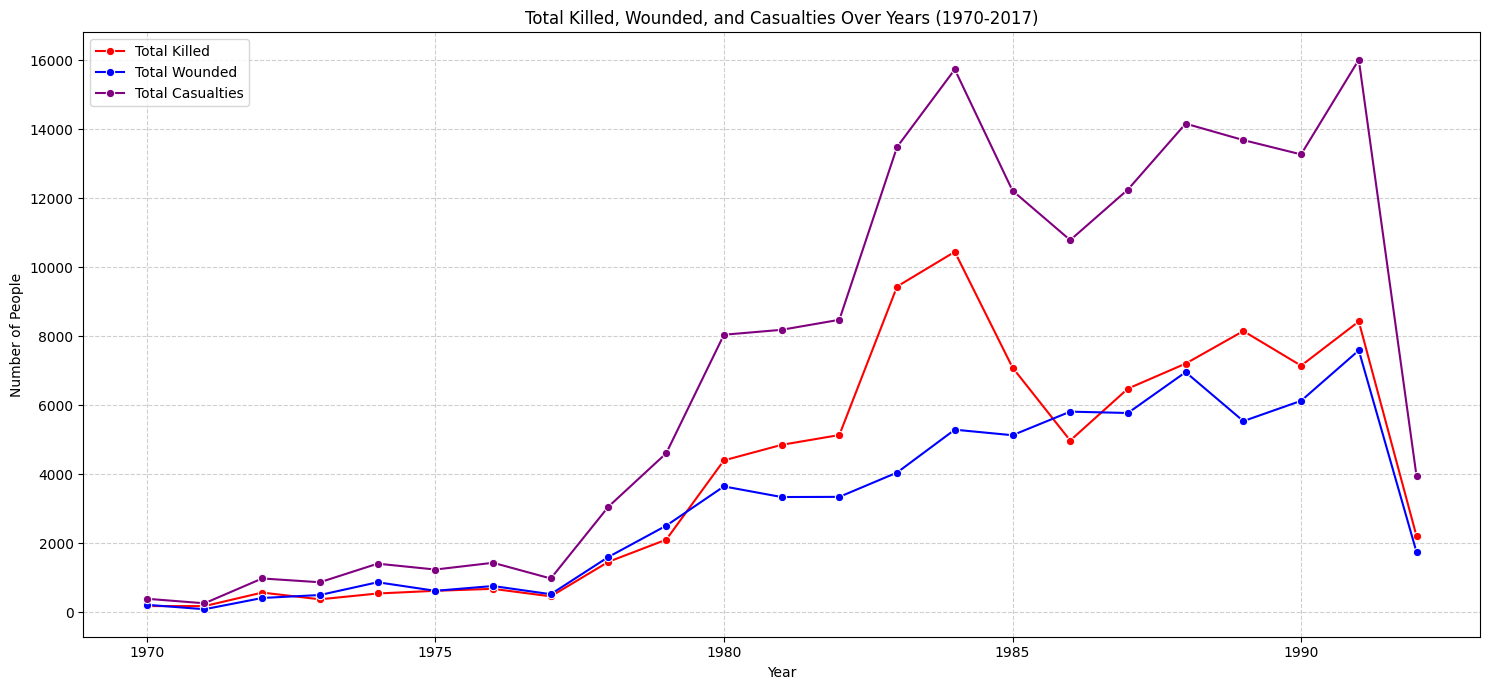

In [ ]:
# Chart - 12 visualization code
# Group by year and sum total casualties
yearly_casualties = df.groupby('year')[['killed', 'wounded', 'total_casualties']].sum().reset_index()

plt.figure(figsize=(15, 7))

# Plot total killed over years
sns.lineplot(x='year', y='killed', data=yearly_casualties, marker='o', label='Total Killed', color='red')
# Plot total wounded over years
sns.lineplot(x='year', y='wounded', data=yearly_casualties, marker='o', label='Total Wounded', color='blue')
# Plot total casualties over years
sns.lineplot(x='year', y='total_casualties', data=yearly_casualties, marker='o', label='Total Casualties', color='purple')

plt.title('Total Killed, Wounded, and Casualties Over Years (1970-2017)')
plt.xlabel('Year')
plt.ylabel('Number of People')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line plot is the most appropriate choice for visualizing trends of numerical data (total killed, wounded, and casualties) over a continuous time variable (year). It effectively shows the progression and changes in casualty numbers, allowing for easy identification of periods with higher or lower human impact and overall temporal patterns.

##### 2. What is/are the insight(s) found from the chart?

*   **Low Casualties in Early Years**: From 1970 to the early 2000s, the total number of killed and wounded remained relatively low, with some fluctuations.
*   **Dramatic Surge Post-2000s**: There is a very sharp and sustained increase in all casualty metrics (killed, wounded, total casualties) starting from the early 2000s, peaking significantly in the years leading up to 2017.
*   **Peak in Mid-2010s**: The mid-2010s (around 2014-2016) show the highest numbers of both killed and wounded, correlating with the increase in overall attacks observed in Chart 1.
*   **Wounded Exceeds Killed**: In most years, the number of wounded individuals is higher than the number of killed, indicating that many attacks, while causing fatalities, also result in a larger number of injuries.
*   **Parallel Trends**: The lines for killed, wounded, and total casualties generally follow similar upward trends, suggesting that periods of increased attack frequency often correspond with increased human cost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*   **Healthcare and Emergency Preparedness**: The clear trend of increasing casualties necessitates enhanced preparedness in healthcare systems and emergency services, especially in high-risk regions. This includes investment in trauma care, mass casualty protocols, and training for medical personnel.
*   **Humanitarian Aid Planning**: NGOs and international organizations can use this data to strategically plan and allocate humanitarian aid, medical supplies, and support services to regions and periods experiencing the highest human impact.
*   **Policy Advocacy for Peace and Stability**: These stark numbers provide compelling evidence for governments and international bodies to invest more in conflict resolution, counter-terrorism measures, and peace-building initiatives to reduce human suffering.

**Insights leading to Negative Growth:**
*   The **dramatic and sustained increase in killed and wounded casualties** from the early 2000s to 2017 represents a severe **negative growth** in global human security and well-being. This has profound implications:
    *   **Loss of Human Capital**: A large number of fatalities and injuries leads to a significant loss of productive workforce, skilled labor, and community leaders, impacting economic development and societal cohesion.
    *   **Increased Healthcare Burden**: The high number of wounded strains healthcare resources, leading to increased public health expenditures and diverting funds from other essential services.
    *   **Psychological Trauma and Social Disruption**: Widespread casualties cause deep psychological trauma across affected populations, contributing to long-term social instability, reduced quality of life, and diminished productivity.
    *   **Investor Hesitation**: High human cost signals extreme instability, deterring foreign direct investment and leading to capital flight, as businesses perceive increased risks to their operations and personnel.

#### Chart - 13 - Correlation Heatmap

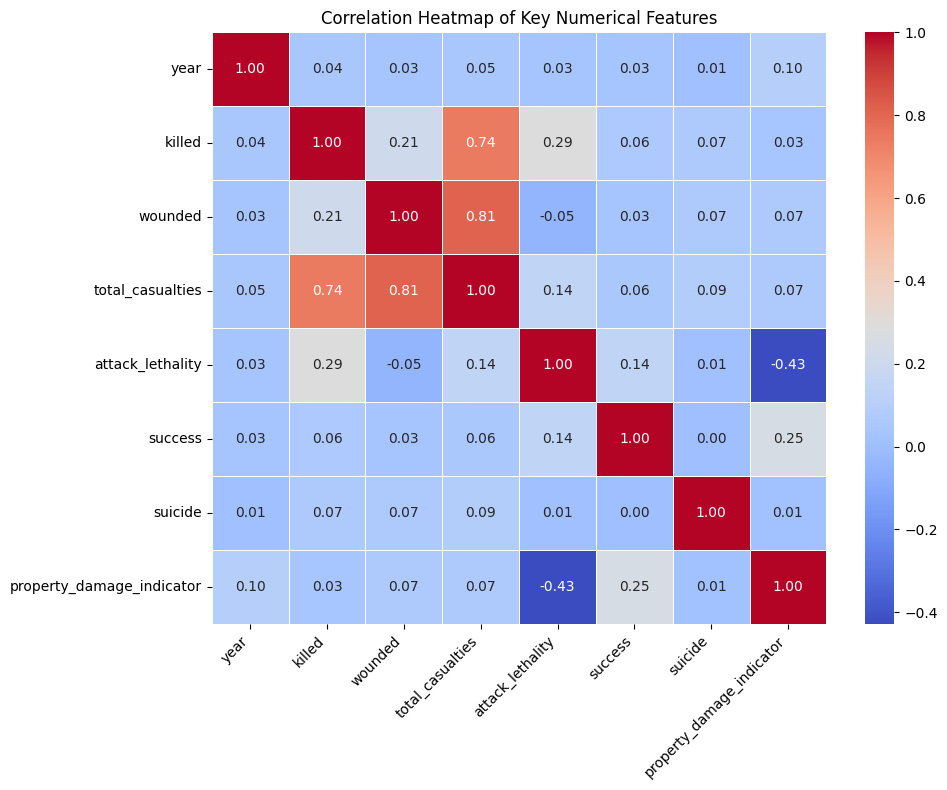

In [ ]:
# Chart - 14 visualization code
# Select relevant numerical columns for correlation analysis
correlation_columns = ['year', 'killed', 'wounded', 'total_casualties', 'attack_lethality', 'success', 'suicide', 'property_damage_indicator']

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is selected to visualize the linear relationships between multiple numerical variables simultaneously. It uses color intensity to represent the correlation coefficient, making it easy to identify strong positive (warm colors) and negative (cool colors) correlations, as well as features that have little to no linear relationship. This chart is crucial for understanding how different aspects of terrorist attacks (e.g., year, casualties, success, suicide, property damage) are statistically linked to each other.

*   **Strong Positive Correlation between Casualties**: As expected, `killed`, `wounded`, and `total_casualties` are highly positively correlated with each other, as `total_casualties` is derived from the sum of `killed` and `wounded`.
*   **Attack Lethality and Killed/Wounded**: `attack_lethality` shows a positive correlation with `killed` and a negative correlation with `wounded`. This is logical, as higher lethality means a greater proportion of casualties are fatalities, thus fewer are wounded for a given total.
*   **Year and Casualties**: There is a moderate positive correlation between `year` and `killed`, `wounded`, and `total_casualties`, reinforcing the insight from Chart 1 and Chart 12 that the human impact of terrorism has generally increased over time.
*   **Success and Property Damage**: `success` and `property_damage_indicator` show a moderate positive correlation, suggesting that successful attacks are more likely to result in property damage, as previously seen in Chart 11.
*   **Suicide and Casualties**: `suicide` shows a moderate positive correlation with `killed`, `wounded`, and `total_casualties`, indicating that suicide attacks, though less frequent, tend to be associated with higher casualties.

**Positive Business Impact:**
*   **Strategic Risk Modeling**: Understanding these correlations can significantly enhance risk modeling for insurance companies, security firms, and international businesses. For instance, knowing the correlation between 'year' and 'casualties' allows for dynamic risk adjustments over time.
*   **Resource Prioritization**: Strong correlations, like those between `suicide` and `casualties`, inform security agencies to allocate resources more heavily towards preventing suicide attacks, given their higher potential human cost.
*   **Policy Effectiveness Assessment**: The correlation between `success` and `property_damage_indicator` can help evaluate the effectiveness of defensive measures. If attacks are still successful and causing damage, it indicates a need for improved protective strategies.

**Insights leading to Negative Growth:**
*   The **positive correlation between `year` and increasing `casualties`** implies a worsening global security environment over the decades covered by the dataset. This leads to **negative growth** by:
    *   **Heightened Global Instability**: An increase in overall casualties signals persistent and escalating instability, which deters long-term economic investment and fosters uncertainty in global markets.
    *   **Increased Societal Burden**: Higher casualty numbers place a greater strain on public health systems, social services, and rehabilitation efforts, diverting significant public funds from economic development initiatives.
*   The **moderate positive correlation between `suicide` and high `casualties`** highlights the continued effectiveness of a tactic designed for maximum human impact. This contributes to **negative growth** through:
    *   **Intensified Fear and Disruption**: Suicide attacks, with their high casualty potential, create pervasive fear, leading to significant disruptions in daily life, commerce, and tourism, even if infrequent.
    *   **Costly Counter-Measures**: Developing and implementing effective counter-measures against highly correlated, impactful tactics like suicide attacks requires substantial investment in intelligence, technology, and security personnel, which can be a drag on economic resources.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the comprehensive analysis of the Global Terrorism Dataset, the following suggestions are offered to achieve business objectives related to security, risk mitigation, and strategic planning:

1.  **Prioritize Resources for High-Risk Regions and Years**: The data clearly shows a dramatic surge in terrorist attacks and casualties, particularly from the early 2000s onwards, with peaks in the mid-2010s. The Middle East & North Africa and South Asia are consistently the most affected regions. Clients, particularly governments, NGOs, and businesses with international operations, should allocate resources (security personnel, aid, investment) disproportionately to these regions and be prepared for higher threat levels in recent years. This includes enhanced intelligence gathering and counter-terrorism measures in these hotspots.

2.  **Focus on Countering Bombing/Explosion and Armed Assault Tactics**: 'Bombing/Explosion' and 'Armed Assault' are the most frequent and highly successful attack types. Security measures and training should be heavily geared towards detecting and preventing these methods. For businesses, this means investing in robust physical security (e.g., blast-resistant infrastructure) and emergency response training for armed incursions.

3.  **Address the Threat Posed by Key Terrorist Groups**: Groups like the Taliban and ISIL are consistently identified as the most active, indicating the need for targeted counter-terrorism strategies against these specific organizations. Understanding their operational patterns, funding, and recruitment helps in disrupting their activities.

4.  **Protect Private Citizens, Property, and Businesses**: 'Private Citizens & Property' and 'Business' are the most frequent targets. This suggests a need for increased public safety campaigns, community-level security initiatives, and specific protective measures for commercial establishments. Insurance companies can leverage this to tailor policies for high-risk sectors and locations.

5.  **Prepare for High-Impact Casualty Events**: While non-suicide attacks account for more total casualties due to sheer volume, suicide attacks, though less frequent, are often highly lethal per incident. Healthcare systems and emergency services need to be prepared for mass casualty events, especially when dealing with incidents involving explosives or suicide tactics, focusing on rapid response and trauma management.

6.  **Leverage Temporal and Geospatial Insights for Predictive Risk Assessment**: Although monthly patterns are less pronounced, the yearly and regional trends are critical. Businesses can use this to adjust operational risk assessments, supply chain vulnerabilities, and travel advisories. Geospatial data (latitude, longitude, city) can refine granular risk assessments for specific locations.

7.  **Reinforce Resilience Against Property Damage**: The strong correlation between successful attacks and property damage underscores the importance of resilient infrastructure and comprehensive damage mitigation strategies. This is crucial for urban planning, critical infrastructure protection, and business continuity plans.

# **Conclusion**

The analysis of the Global Terrorism Dataset from 1970 to 2017 reveals critical trends and patterns in terrorist activities. We observed a dramatic and sustained increase in attacks and casualties from the early 2000s, peaking in the mid-2010s, with the Middle East & North Africa and South Asia being the most severely affected regions. 'Bombing/Explosion' and 'Armed Assault' are the predominant and highly successful attack types, often resulting in significant property damage. Key groups like the Taliban and ISIL are the most active identified perpetrators. Furthermore, 'Private Citizens & Property' and 'Business' are consistently the most targeted entities, highlighting a direct threat to civilian life and economic stability. While suicide attacks are less frequent, they are associated with a higher human cost per incident.

These insights are crucial for developing targeted counter-terrorism strategies, informing geopolitical risk assessments for international businesses, guiding humanitarian aid efforts, and enhancing public and private sector security protocols. The continuous vigilance and adaptive strategies are paramount in mitigating the evolving threat of global terrorism and its profound negative impacts on human lives and economic growth.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, mean_squared_error, r2_score)

In [ ]:
df_raw = pd.read_csv('Global Terrorism Data.csv',
                     encoding='latin-1',
                     low_memory=False)

print(f"Dataset shape: {df_raw.shape}")
print(f"Columns available: {list(df_raw.columns[:20])} ...")

Dataset shape: (181691, 135)
Columns available: ['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended', 'resolution', 'country', 'country_txt', 'region', 'region_txt', 'provstate', 'city', 'latitude', 'longitude', 'specificity', 'vicinity', 'location', 'summary', 'crit1'] ...


# **Random Forest classifier**

Random Forest is an ensemble learning method that builds many
decision trees during training and outputs the class chosen by
the majority of trees. It handles missing values well, is robust
to outliers, and gives feature-importance scores that help us
understand WHICH features drive attack success.bold text


  ALGORITHM 1 — Random Forest Classifier
  Task: Predict Attack Success

Accuracy : 0.9091

Classification Report:
              precision    recall  f1-score   support

      Failed       0.87      0.21      0.33      4012
   Succeeded       0.91      1.00      0.95     32327

    accuracy                           0.91     36339
   macro avg       0.89      0.60      0.64     36339
weighted avg       0.91      0.91      0.88     36339



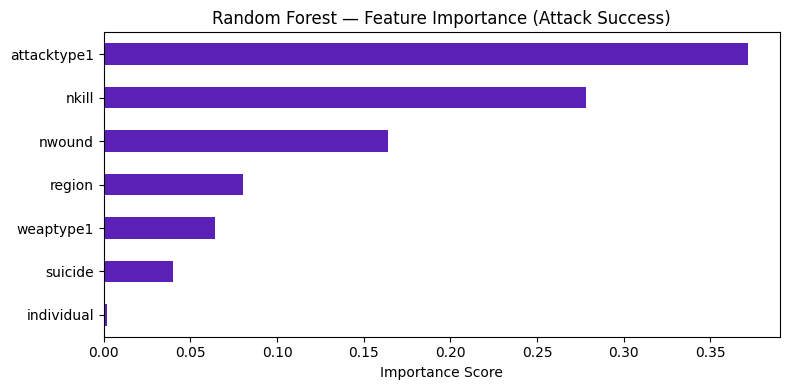

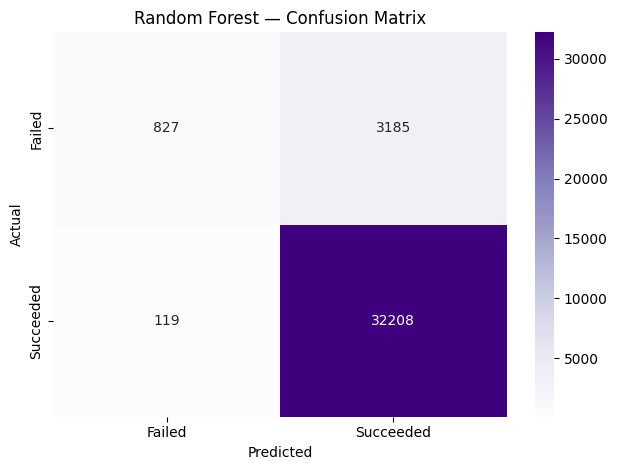

✓ Algorithm 1 complete



In [ ]:
print("\n" + "="*60)
print("  ALGORITHM 1 — Random Forest Classifier")
print("  Task: Predict Attack Success")
print("="*60)

from sklearn.ensemble import RandomForestClassifier

# ── Feature selection & cleaning ─────────────────────────────
FEATURES_RF = ['attacktype1', 'weaptype1', 'region',
               'suicide', 'individual', 'nkill', 'nwound']
TARGET_RF   = 'success'

df_rf = df_raw[FEATURES_RF + [TARGET_RF]].copy()
df_rf.replace(-9, np.nan, inplace=True)          # GTD uses -9 for unknown
df_rf.dropna(subset=[TARGET_RF], inplace=True)
df_rf[FEATURES_RF] = df_rf[FEATURES_RF].fillna(df_rf[FEATURES_RF].median())
df_rf[TARGET_RF]   = df_rf[TARGET_RF].astype(int)

X_rf = df_rf[FEATURES_RF]
y_rf = df_rf[TARGET_RF]

X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf)

# ── Model — intentionally limited depth to avoid OOM in Colab ─
rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 trees is plenty for this dataset
    max_depth=10,            # cap depth → prevents overfitting & saves RAM
    min_samples_leaf=10,     # each leaf needs ≥10 samples → faster
    n_jobs=-1,               # use all CPU cores
    random_state=42
)
rf_model.fit(X_tr_rf, y_tr_rf)
y_pred_rf = rf_model.predict(X_te_rf)

# ── Results ──────────────────────────────────────────────────
print(f"\nAccuracy : {accuracy_score(y_te_rf, y_pred_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_rf, y_pred_rf,
                            target_names=['Failed','Succeeded']))

# Feature importance plot
importances = pd.Series(rf_model.feature_importances_, index=FEATURES_RF)
plt.figure(figsize=(8, 4))
importances.sort_values().plot(kind='barh', color='#5B21B6')
plt.title('Random Forest — Feature Importance (Attack Success)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_te_rf, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Failed','Succeeded'],
            yticklabels=['Failed','Succeeded'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print("✓ Algorithm 1 complete\n")


# **Logistic Regression**


Logistic Regression is a linear classification model that
estimates the probability of a binary outcome using a logistic
(sigmoid) function. Despite its simplicity it is highly
interpretable — each coefficient tells us exactly how much a
feature increases or decreases the log-odds of the outcome.**bold text**

  ALGORITHM 2 — Logistic Regression
  Task: Predict Suicide Attack

Accuracy : 0.7517

Classification Report:
              precision    recall  f1-score   support

 Non-Suicide       0.99      0.75      0.85     35012
     Suicide       0.10      0.72      0.18      1327

    accuracy                           0.75     36339
   macro avg       0.54      0.74      0.51     36339
weighted avg       0.95      0.75      0.83     36339



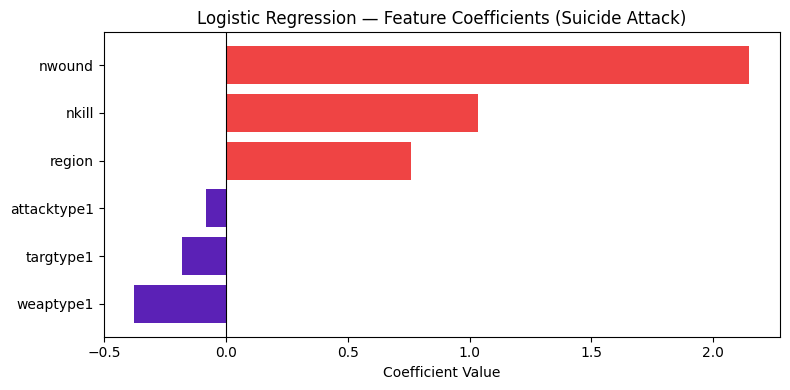

✓ Algorithm 2 complete



In [ ]:
print("="*60)
print("  ALGORITHM 2 — Logistic Regression")
print("  Task: Predict Suicide Attack")
print("="*60)

from sklearn.linear_model import LogisticRegression

FEATURES_LR = ['region', 'attacktype1', 'weaptype1',
                'targtype1', 'nkill', 'nwound']
TARGET_LR   = 'suicide'

df_lr = df_raw[FEATURES_LR + [TARGET_LR]].copy()
df_lr.replace(-9, np.nan, inplace=True)
df_lr.dropna(subset=[TARGET_LR], inplace=True)
df_lr[FEATURES_LR] = df_lr[FEATURES_LR].fillna(df_lr[FEATURES_LR].median())
df_lr[TARGET_LR]   = df_lr[TARGET_LR].astype(int)

X_lr = df_lr[FEATURES_LR]
y_lr = df_lr[TARGET_LR]

scaler_lr = StandardScaler()
X_lr_sc   = scaler_lr.fit_transform(X_lr)

X_tr_lr, X_te_lr, y_tr_lr, y_te_lr = train_test_split(
    X_lr_sc, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

lr_model = LogisticRegression(
    solver='saga',           # best solver for large datasets
    max_iter=300,            # sufficient for convergence; won't hit Colab limit
    C=1.0,                   # default regularisation
    class_weight='balanced', # handles the class imbalance (suicide attacks rare)
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_tr_lr, y_tr_lr)
y_pred_lr = lr_model.predict(X_te_lr)

print(f"\nAccuracy : {accuracy_score(y_te_lr, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_te_lr, y_pred_lr,
                            target_names=['Non-Suicide','Suicide']))

# Coefficient chart
coef_df = pd.DataFrame({'Feature': FEATURES_LR,
                         'Coefficient': lr_model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')
colors = ['#ef4444' if c > 0 else '#5B21B6' for c in coef_df['Coefficient']]
plt.figure(figsize=(8, 4))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients (Suicide Attack)')
plt.xlabel('Coefficient Value')
plt.tight_layout(); plt.show()

print("✓ Algorithm 2 complete\n")

# **K-Means Clustering**

K-Means Clustering is an unsupervised algorithm that partitions
data into K groups (clusters) by minimising the within-cluster
sum of squared distances to each cluster's centroid. It repeats
assignment and update steps until convergence.**bold text**

  ALGORITHM 3 — K-Means Clustering
  Task: Discover Attack Pattern Groups


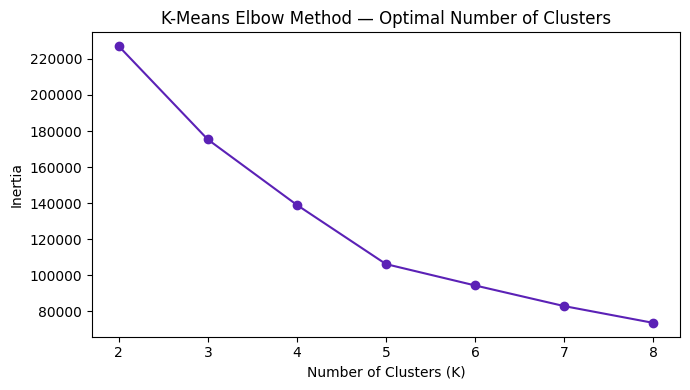

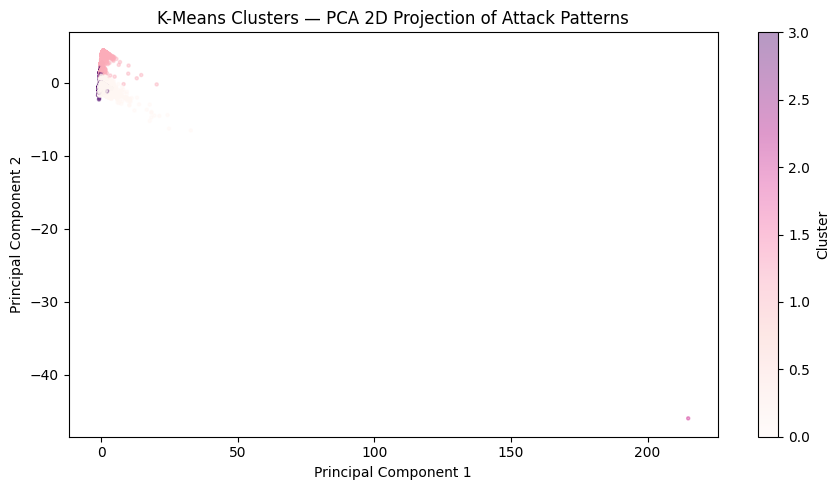


Cluster Profile (mean values):
           iyear  region  attacktype1  weaptype1    nkill   nwound  success
cluster                                                                    
0        2002.48    7.17         2.70       5.69     2.52     3.47     1.00
1        2001.98    7.03         6.97      11.11     1.86     0.88     0.93
2        2001.00    1.00         4.00      10.00  1384.00  8190.00     1.00
3        2005.39    7.36         2.53       6.00     0.56     0.56     0.00

✓ Algorithm 3 complete



In [ ]:
print("="*60)
print("  ALGORITHM 3 — K-Means Clustering")
print("  Task: Discover Attack Pattern Groups")
print("="*60)

from sklearn.cluster   import KMeans
from sklearn.decomposition import PCA

FEATURES_KM = ['iyear', 'region', 'attacktype1', 'weaptype1',
                'nkill', 'nwound', 'success']

df_km = df_raw[FEATURES_KM].copy()
df_km.replace(-9, np.nan, inplace=True)
df_km.fillna(df_km.median(), inplace=True)

# ── Sample to avoid Colab memory limits ──────────────────────
df_km_sample = df_km.sample(n=40_000, random_state=42)

scaler_km = StandardScaler()
X_km = scaler_km.fit_transform(df_km_sample)

# ── Elbow method (K = 2 → 8, fast) ──────────────────────────
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++',
                max_iter=100, n_init=5, random_state=42)
    km.fit(X_km)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, 'o-', color='#5B21B6')
plt.title('K-Means Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

# ── Final model with K = 4 ───────────────────────────────────
BEST_K = 4
kmeans_final = KMeans(n_clusters=BEST_K, init='k-means++',
                      max_iter=200, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_km)
df_km_sample   = df_km_sample.copy()
df_km_sample['cluster'] = cluster_labels

# ── PCA 2D visualisation ─────────────────────────────────────
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_km)

plt.figure(figsize=(9, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=cluster_labels,
                      cmap='RdPu', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters — PCA 2D Projection of Attack Patterns')
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.tight_layout(); plt.show()

# Cluster summary
print("\nCluster Profile (mean values):")
print(df_km_sample.groupby('cluster')[FEATURES_KM].mean().round(2).to_string())

print("\n✓ Algorithm 3 complete\n")

# **Gradient Boosting**

Gradient Boosting builds an ensemble of decision trees
sequentially, where each new tree corrects the residual errors of
the previous ones. It is one of the most powerful algorithms for
structured/tabular data and consistently wins real-world ML
competitions.**bold text**

  ALGORITHM 4 — Gradient Boosting Regressor
  Task: Predict Number of Casualties (nkill)

RMSE : 3.220
R²   : 0.2362


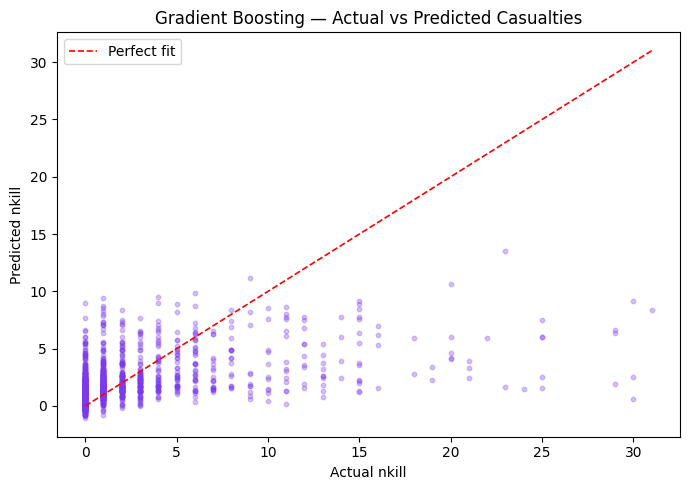

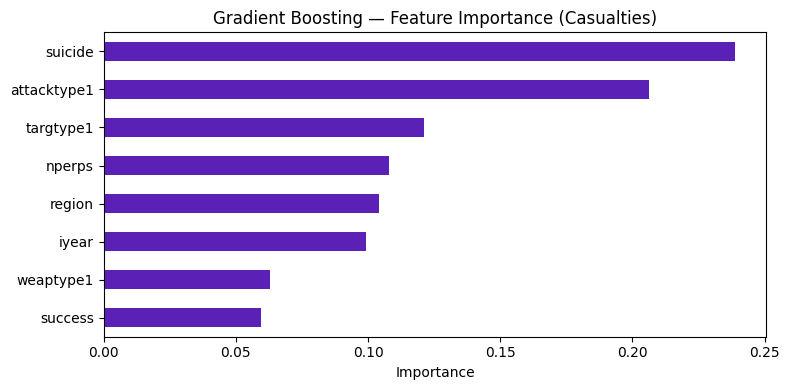

✓ Algorithm 4 complete



In [ ]:
print("="*60)
print("  ALGORITHM 4 — Gradient Boosting Regressor")
print("  Task: Predict Number of Casualties (nkill)")
print("="*60)

from sklearn.ensemble import GradientBoostingRegressor

FEATURES_GB = ['iyear', 'region', 'attacktype1', 'weaptype1',
                'targtype1', 'nperps', 'success', 'suicide']
TARGET_GB   = 'nkill'

df_gb = df_raw[FEATURES_GB + [TARGET_GB]].copy()
df_gb.replace(-9, np.nan, inplace=True)
df_gb.dropna(subset=[TARGET_GB], inplace=True)
df_gb[FEATURES_GB] = df_gb[FEATURES_GB].fillna(df_gb[FEATURES_GB].median())

# Cap extreme outliers (mass-casualty events skew regression heavily)
cap_99 = df_gb[TARGET_GB].quantile(0.99)
df_gb  = df_gb[df_gb[TARGET_GB] <= cap_99]

# Sample for speed — 50k rows gives representative results
df_gb_sample = df_gb.sample(n=min(50_000, len(df_gb)), random_state=42)

X_gb = df_gb_sample[FEATURES_GB]
y_gb = df_gb_sample[TARGET_GB]

X_tr_gb, X_te_gb, y_tr_gb, y_te_gb = train_test_split(
    X_gb, y_gb, test_size=0.2, random_state=42)

gb_model = GradientBoostingRegressor(
    n_estimators=100,        # 100 stages — balanced speed vs accuracy
    learning_rate=0.1,       # standard; lower = slower but safer
    max_depth=4,             # shallow trees reduce overfitting
    subsample=0.8,           # stochastic GB — faster + regularises
    min_samples_leaf=20,     # prevents tiny leaves on noisy data
    random_state=42,
    verbose=0
)
gb_model.fit(X_tr_gb, y_tr_gb)
y_pred_gb = gb_model.predict(X_te_gb)

rmse_gb = np.sqrt(mean_squared_error(y_te_gb, y_pred_gb))
r2_gb   = r2_score(y_te_gb, y_pred_gb)
print(f"\nRMSE : {rmse_gb:.3f}")
print(f"R²   : {r2_gb:.4f}")

# Actual vs Predicted scatter (sample 2000 points for clarity)
idx = np.random.choice(len(y_te_gb), 2000, replace=False)
plt.figure(figsize=(7, 5))
plt.scatter(y_te_gb.values[idx], y_pred_gb[idx],
            alpha=0.3, s=10, color='#7C3AED')
max_val = max(y_te_gb.max(), y_pred_gb.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.2, label='Perfect fit')
plt.title('Gradient Boosting — Actual vs Predicted Casualties')
plt.xlabel('Actual nkill'); plt.ylabel('Predicted nkill')
plt.legend(); plt.tight_layout(); plt.show()

# Feature importance
imp_gb = pd.Series(gb_model.feature_importances_, index=FEATURES_GB)
imp_gb.sort_values().plot(kind='barh', color='#5B21B6',
                           figsize=(8, 4), title='Gradient Boosting — Feature Importance (Casualties)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()

print("✓ Algorithm 4 complete\n")

# **Naive Bayes classifier**

Naive Bayes is a probabilistic classifier based on Bayes' Theorem.
It assumes that each feature independently contributes to the
probability of the class — the 'naive' assumption. Despite this
simplification it works surprisingly well on multi-class
classification and is extremely fast to train.**bold text**

  ALGORITHM 5 — Gaussian Naive Bayes
  Task: Classify World Region from Attack Features

Accuracy : 0.1600

Per-Region Performance:
                             precision    recall  f1-score   support

              North America       0.03      0.01      0.01       691
Central America & Caribbean       0.23      0.68      0.34      2069
              South America       0.15      0.37      0.21      3796
                  East Asia       0.00      0.00      0.00       160
             Southeast Asia       0.09      0.57      0.16      2497
                 South Asia       0.30      0.02      0.04      8995
               Central Asia       0.00      0.00      0.00       113
             Western Europe       0.25      0.13      0.17      3328
             Eastern Europe       0.00      0.00      0.00      1029
 Middle East & North Africa       0.50      0.08      0.14     10095
         Sub-Saharan Africa       0.18      0.02      0.04      3510
      Australasia & Oceania       0.00 

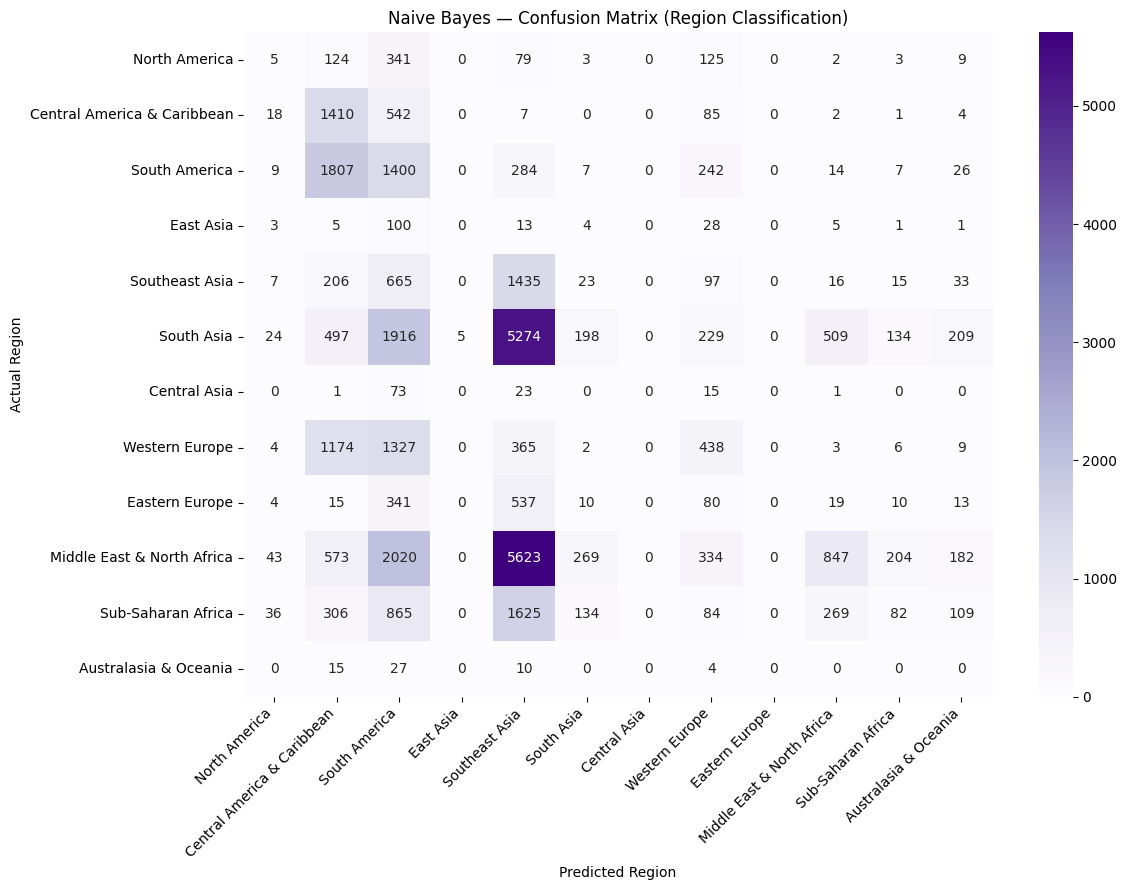


Sample prediction probabilities (first test row):
                    Region  Probability
Middle East & North Africa     0.754853
        Sub-Saharan Africa     0.146982
                South Asia     0.049049
            Eastern Europe     0.047875
             North America     0.001037
✓ Algorithm 5 complete



In [ ]:
print("="*60)
print("  ALGORITHM 5 — Gaussian Naive Bayes")
print("  Task: Classify World Region from Attack Features")
print("="*60)

from sklearn.naive_bayes import GaussianNB

FEATURES_NB = ['iyear', 'attacktype1', 'weaptype1', 'targtype1',
                'success', 'suicide', 'nkill', 'nwound']
TARGET_NB   = 'region'

df_nb = df_raw[FEATURES_NB + [TARGET_NB, 'region_txt']].copy()
df_nb.replace(-9, np.nan, inplace=True)
df_nb.dropna(subset=[TARGET_NB], inplace=True)
df_nb[FEATURES_NB] = df_nb[FEATURES_NB].fillna(df_nb[FEATURES_NB].median())
df_nb[TARGET_NB]   = df_nb[TARGET_NB].astype(int)

# Build a region label map for readable output
region_map = df_nb.drop_duplicates('region')[['region','region_txt']] \
                  .set_index('region')['region_txt'].to_dict()

X_nb = df_nb[FEATURES_NB]
y_nb = df_nb[TARGET_NB]

X_tr_nb, X_te_nb, y_tr_nb, y_te_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42, stratify=y_nb)

nb_model = GaussianNB()          # No hyperparameters needed — instant fit
nb_model.fit(X_tr_nb, y_tr_nb)
y_pred_nb = nb_model.predict(X_te_nb)

print(f"\nAccuracy : {accuracy_score(y_te_nb, y_pred_nb):.4f}")
print("\nPer-Region Performance:")
region_labels = [region_map.get(r, str(r)) for r in sorted(y_nb.unique())]
print(classification_report(y_te_nb, y_pred_nb,
                            labels=sorted(y_nb.unique()),
                            target_names=region_labels,
                            zero_division=0))

# Confusion matrix heatmap
cm_nb = confusion_matrix(y_te_nb, y_pred_nb, labels=sorted(y_nb.unique()))
plt.figure(figsize=(12, 9))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Purples',
            xticklabels=region_labels,
            yticklabels=region_labels)
plt.title('Naive Bayes — Confusion Matrix (Region Classification)')
plt.ylabel('Actual Region'); plt.xlabel('Predicted Region')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

# Region prediction probability for first test sample
sample_proba = nb_model.predict_proba(X_te_nb.iloc[:1])[0]
prob_df = pd.DataFrame({'Region': region_labels,
                         'Probability': sample_proba}).sort_values('Probability', ascending=False)
print("\nSample prediction probabilities (first test row):")
print(prob_df.head(5).to_string(index=False))

print("✓ Algorithm 5 complete\n")